# 🎯 Introduction

FIFA video games have become more than just entertainment — they reflect real-world football dynamics, offering a rich dataset of player attributes updated annually. This project explores player statistics from FIFA 17 to FIFA 22 to uncover trends, understand what defines top-tier players, and analyze how attributes evolve over time.

## Objectives
- Identify which attributes correlate most with overall player performance.
- Track how the top 10 players evolve across multiple FIFA editions.
- Compare player profiles (e.g., Messi vs Ronaldo) to understand unique strengths.
- Use data visualization and statistical techniques to draw meaningful insights.

As avid FIFA players, we were also personally motivated to understand the attributes that make players "feel" elite during gameplay.

## Github Link
**https://github.com/aaryanpatil/fifa-22-analysis**


# 🧪 Materials and Methods

## Dataset
We used official FIFA player data spanning from **FIFA 17 to FIFA 22**, sourced from Kaggle. Each edition includes detailed player attributes such as dribbling, shooting, pace, physical, and goalkeeper skills.

### Preprocessing Pipeline:
- Merged CSV files for FIFA 17 to 22 into a single DataFrame.
- Removed non-representative players (e.g., SUB/RES, those with low International Reputation).
- Cleaned and converted height and weight units.
- Standardized player positions and removed duplicates.
- Encoded categorical variables as necessary.

## Methodology
- Exploratory Data Analysis: Distributions, scatterplots, heatmaps.
- Correlation Analysis: Pearson and Spearman to detect both linear and monotonic relationships.
- Time Series Tracking: Evolution of top players across years.
- Dimensionality Reduction: For visualization of multi-attribute trends.
- Comparative Player Analysis: Side-by-side bar plots of specific attribute sets.


In [1]:
pip install plotly

In [3]:
import pandas as pd
import seaborn as sns
import numpy as np
import math
import matplotlib.pyplot as plt
import re
import plotly.express as px
from scipy.stats import spearmanr
# Load your merged dataset
df = pd.read_csv('output/fifa_merged.csv')

# Quick look
df.head()

C:\Users\vinay\AppData\Local\Temp\ipykernel_31460\254176837.py:10: DtypeWarning: Columns (64) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('output/fifa_merged.csv')


,ID,Name,Age,Photo,Nationality,Flag,Overall,Potential,Club,Club Logo,...,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Best Position,Best Overall Rating,Year,Release Clause,DefensiveAwareness
0,176580,L. Suárez,29,https://cdn.sofifa.com/players/176/580/17_60.png,Uruguay,https://cdn.sofifa.com/flags/uy.png,92,92,FC Barcelona,https://cdn.sofifa.com/teams/241/light_30.png,...,27.0,25.0,31.0,33.0,37.0,ST,88.0,2017,NaN,NaN
1,178518,R. Nainggolan,28,https://cdn.sofifa.com/players/178/518/17_60.png,Belgium,https://cdn.sofifa.com/flags/be.png,86,86,Roma,https://cdn.sofifa.com/teams/52/light_30.png,...,11.0,11.0,14.0,8.0,11.0,CDM,84.0,2017,NaN,NaN
2,181872,A. Vidal,29,https://cdn.sofifa.com/players/181/872/17_60.png,Chile,https://cdn.sofifa.com/flags/cl.png,87,87,FC Bayern München,https://cdn.sofifa.com/teams/21/light_30.png,...,4.0,2.0,4.0,2.0,4.0,CDM,85.0,2017,NaN,NaN
3,197445,D. Alaba,24,https://cdn.sofifa.com/players/197/445/17_60.png,Austria,https://cdn.sofifa.com/flags/at.png,86,89,FC Bayern München,https://cdn.sofifa.com/teams/21/light_30.png,...,5.0,7.0,14.0,15.0,9.0,LB,84.0,2017,NaN,NaN
4,195864,P. Pogba,23,https://cdn.sofifa.com/players/195/864/17_60.png,France,https://cdn.sofifa.com/flags/fr.png,88,94,Manchester United,https://cdn.sofifa.com/teams/11/light_30.png,...,5.0,6.0,2.0,4.0,3.0,CAM,85.0,2017,NaN,NaN


In [4]:
# Shape of dataset
print(f"Dataset shape: {df.shape}")

Dataset shape: (104352, 66)


In [5]:
# Columns
df.columns.tolist()

['ID',
 'Name',
 'Age',
 'Photo',
 'Nationality',
 'Flag',
 'Overall',
 'Potential',
 'Club',
 'Club Logo',
 'Value',
 'Wage',
 'Special',
 'Preferred Foot',
 'International Reputation',
 'Weak Foot',
 'Skill Moves',
 'Work Rate',
 'Body Type',
 'Real Face',
 'Position',
 'Jersey Number',
 'Joined',
 'Loaned From',
 'Contract Valid Until',
 'Height',
 'Weight',
 'Crossing',
 'Finishing',
 'HeadingAccuracy',
 'ShortPassing',
 'Volleys',
 'Dribbling',
 'Curve',
 'FKAccuracy',
 'LongPassing',
 'BallControl',
 'Acceleration',
 'SprintSpeed',
 'Agility',
 'Reactions',
 'Balance',
 'ShotPower',
 'Jumping',
 'Stamina',
 'Strength',
 'LongShots',
 'Aggression',
 'Interceptions',
 'Positioning',
 'Vision',
 'Penalties',
 'Composure',
 'Marking',
 'StandingTackle',
 'SlidingTackle',
 'GKDiving',
 'GKHandling',
 'GKKicking',
 'GKPositioning',
 'GKReflexes',
 'Best Position',
 'Best Overall Rating',
 'Year',
 'Release Clause',
 'DefensiveAwareness']

In [6]:
# Show only columns where missing values > 0
missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

Loaned From             96509
DefensiveAwareness      56950
Marking                 47402
Release Clause          26844
Joined                  10461
Contract Valid Until     2536
Club                     1710
Composure                 958
Jersey Number             117
Position                  117
Volleys                   115
Curve                     115
Balance                   115
Jumping                   115
Vision                    115
SlidingTackle             115
Agility                   115
Body Type                  81
Real Face                  81
Interceptions              15
Positioning                15
dtype: int64

In [7]:
columns_to_drop = [
    'Photo', 'Flag', 'Club Logo', 'Loaned From', 'DefensiveAwareness',
    'Marking', 'Release Clause', 'Joined', 'Contract Valid Until',
    'Jersey Number', 'Body Type', 'Real Face', 'Special', 'Best Position', 'Best Overall Rating'
]

In [8]:
# Drop columns
df_cleaned = df.drop(columns=columns_to_drop)

# Drop rows where important columns are missing
important_columns_for_rows = [
    'Club', 'Composure', 'Position', 'Balance', 'Jumping', 'Volleys',
    'Vision', 'SlidingTackle', 'Agility', 'Curve', 'Interceptions', 'Positioning'
]

df_cleaned = df_cleaned.dropna(subset=important_columns_for_rows)

print(f"Shape after full cleaning: {df_cleaned.shape}")
df_cleaned.head()


Shape after full cleaning: (101760, 51)


,ID,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred Foot,...,Penalties,Composure,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Year
0,176580,L. Suárez,29,Uruguay,92,92,FC Barcelona,€83M,€525K,Right,...,85.0,83.0,45.0,38.0,27.0,25.0,31.0,33.0,37.0,2017
1,178518,R. Nainggolan,28,Belgium,86,86,Roma,€37.5M,€130K,Right,...,63.0,85.0,85.0,88.0,11.0,11.0,14.0,8.0,11.0,2017
2,181872,A. Vidal,29,Chile,87,87,FC Bayern München,€41.5M,€180K,Right,...,84.0,86.0,89.0,84.0,4.0,2.0,4.0,2.0,4.0,2017
3,197445,D. Alaba,24,Austria,86,89,FC Bayern München,€41.5M,€140K,Left,...,80.0,79.0,83.0,83.0,5.0,7.0,14.0,15.0,9.0,2017
4,195864,P. Pogba,23,France,88,94,Manchester United,€71.5M,€225K,Right,...,76.0,83.0,73.0,73.0,5.0,6.0,2.0,4.0,3.0,2017


In [9]:
def clean_position(pos):
    if pd.isnull(pos):
        return None
    # Extract just the position letters (remove HTML tags)
    match = re.search(r'>([A-Z]+)', pos)
    if match:
        return match.group(1)
    else:
        return pos.strip()  # fallback

# Apply cleaning
df_cleaned['Position'] = df_cleaned['Position'].apply(clean_position)

# Quick check
df_cleaned['Position'].value_counts()

Position
SUB    43588
RES    17956
RCB     3586
LCB     3582
GK      3478
RB      2976
LB      2967
ST      2610
RM      2401
LM      2354
LCM     2230
RCM     2225
CAM     1781
RDM     1357
LDM     1356
LS      1215
RS      1213
CDM      869
LW       862
RW       842
CB       625
CM       398
RWB      378
LWB      377
RAM      139
LAM      132
LF        99
RF        98
CF        66
Name: count, dtype: int64

In [10]:
# Remove rows where Position is 'SUB' or 'RES'
df_cleaned = df_cleaned[~df_cleaned['Position'].isin(['SUB', 'RES'])]

print(f"Shape after removing SUB/RES players: {df_cleaned.shape}")

Shape after removing SUB/RES players: (40216, 51)


In [11]:
def height_to_inches(height):
    if pd.isnull(height):
        return None
    height = height.strip()
    
    # Case 1: Height is in cm
    if 'cm' in height:
        cm_val = float(height.replace('cm', '').strip())
        return cm_val * 0.393701  # 1 cm = 0.393701 inches
    
    # Case 2: Height is in feet'inches (like 5'9)
    elif "'" in height:
        parts = height.split("'")
        if len(parts) == 2:
            try:
                feet = int(parts[0])
                inches = int(parts[1])
                return feet * 12 + inches
            except ValueError:
                return None  # in case it's broken
    else:
        return None  # fallback if unexpected format

# Apply again to your data
df_cleaned['Height_in_inches'] = df_cleaned['Height'].apply(height_to_inches)


In [12]:
def clean_weight(w):
    if pd.isnull(w):
        return None
    w = w.strip()
    if 'lbs' in w:
        return int(w.replace('lbs', '').strip())
    elif 'kg' in w:
        kg_val = float(w.replace('kg', '').strip())
        return int(kg_val * 2.20462)  # Convert kg to lbs
    else:
        return None  # fallback if unexpected format

# Apply it again
df_cleaned['Weight_lbs'] = df_cleaned['Weight'].apply(clean_weight)

# Optional: drop the old 'Weight' column now if you want
df_cleaned = df_cleaned.drop(columns=['Weight'])


In [13]:
df_cleaned.head()

,ID,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred Foot,...,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Year,Height_in_inches,Weight_lbs
0,176580,L. Suárez,29,Uruguay,92,92,FC Barcelona,€83M,€525K,Right,...,45.0,38.0,27.0,25.0,31.0,33.0,37.0,2017,72.0,190
1,178518,R. Nainggolan,28,Belgium,86,86,Roma,€37.5M,€130K,Right,...,85.0,88.0,11.0,11.0,14.0,8.0,11.0,2017,69.0,143
2,181872,A. Vidal,29,Chile,87,87,FC Bayern München,€41.5M,€180K,Right,...,89.0,84.0,4.0,2.0,4.0,2.0,4.0,2017,71.0,165
3,197445,D. Alaba,24,Austria,86,89,FC Bayern München,€41.5M,€140K,Left,...,83.0,83.0,5.0,7.0,14.0,15.0,9.0,2017,71.0,168
4,195864,P. Pogba,23,France,88,94,Manchester United,€71.5M,€225K,Right,...,73.0,73.0,5.0,6.0,2.0,4.0,3.0,2017,75.0,185


In [14]:
df_cleaned.describe()

,ID,Age,Overall,Potential,International Reputation,Weak Foot,Skill Moves,Crossing,Finishing,HeadingAccuracy,...,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Year,Height_in_inches,Weight_lbs
count,40216.000000,40216.000000,40216.00000,40216.000000,40216.000000,40216.000000,40216.000000,40216.000000,40216.000000,40216.000000,...,40216.000000,40216.000000,40216.000000,40216.000000,40216.000000,40216.000000,40216.000000,40216.000000,40216.000000,40216.000000
mean,209974.046126,26.209966,69.67222,72.930625,1.183683,3.021036,2.474960,53.941416,48.763577,55.850408,...,52.164139,49.630296,15.774219,15.588025,15.452357,15.655983,15.888900,2019.451686,71.411202,166.901358
std,31545.388429,4.274409,6.03990,6.059403,0.508149,0.685078,0.782991,17.992576,19.513976,16.886392,...,21.415626,21.297419,17.332773,16.541880,16.078835,16.931540,17.702683,1.712989,2.667134,15.538378
min,16.000000,16.000000,47.00000,49.000000,1.000000,1.000000,1.000000,6.000000,3.000000,4.000000,...,2.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2017.000000,61.000000,110.000000
25%,193900.000000,23.000000,66.00000,69.000000,1.000000,3.000000,2.000000,44.000000,33.000000,49.000000,...,33.000000,29.000000,8.000000,8.000000,8.000000,8.000000,8.000000,2018.000000,69.685077,156.000000
50%,213742.500000,26.000000,69.00000,73.000000,1.000000,3.000000,2.000000,59.000000,52.000000,59.000000,...,61.000000,58.000000,11.000000,11.000000,11.000000,11.000000,11.000000,2019.000000,71.259881,165.000000
75%,231356.000000,29.000000,73.00000,77.000000,1.000000,3.000000,3.000000,67.000000,65.000000,68.000000,...,69.000000,67.000000,14.000000,14.000000,14.000000,14.000000,14.000000,2021.000000,73.000000,176.000000
max,264673.000000,44.000000,94.00000,95.000000,5.000000,5.000000,5.000000,94.000000,95.000000,94.000000,...,93.000000,95.000000,91.000000,92.000000,93.000000,92.000000,93.000000,2022.000000,81.000000,243.000000


In [15]:
# Filter players with International Reputation >= 3.0
df_cleaned = df_cleaned[df_cleaned['International Reputation'] >= 3.0]

In [16]:
df_cleaned.describe()

,ID,Age,Overall,Potential,International Reputation,Weak Foot,Skill Moves,Crossing,Finishing,HeadingAccuracy,...,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Year,Height_in_inches,Weight_lbs
count,1507.000000,1507.000000,1507.000000,1507.000000,1507.000000,1507.000000,1507.000000,1507.000000,1507.000000,1507.000000,...,1507.000000,1507.000000,1507.000000,1507.000000,1507.000000,1507.000000,1507.000000,1507.000000,1507.000000,1507.000000
mean,174201.232250,29.641009,82.425348,83.192435,3.211015,3.355010,2.982747,63.464499,60.954214,63.597213,...,55.252820,52.188454,18.205707,17.846715,17.554081,17.944260,18.211015,2019.684141,71.796830,171.136032
std,43541.568481,3.923978,4.512514,5.040882,0.460164,0.793847,1.078447,21.746256,23.418841,21.382784,...,26.377264,26.758083,23.055655,22.421141,21.095532,23.079534,23.623695,1.701427,2.781680,16.907904
min,41.000000,18.000000,60.000000,60.000000,3.000000,1.000000,1.000000,9.000000,8.000000,10.000000,...,10.000000,8.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2017.000000,64.000000,127.000000
25%,165229.000000,27.000000,80.000000,80.000000,3.000000,3.000000,2.000000,56.000000,47.500000,54.500000,...,31.000000,26.000000,8.000000,8.000000,8.000000,7.000000,8.000000,2018.000000,70.000000,159.000000
50%,183280.000000,30.000000,83.000000,83.000000,3.000000,3.000000,3.000000,71.000000,68.000000,70.000000,...,59.000000,55.000000,11.000000,11.000000,11.000000,11.000000,10.000000,2020.000000,72.000000,170.000000
75%,199069.000000,33.000000,85.000000,87.000000,3.000000,4.000000,4.000000,79.000000,78.000000,80.000000,...,81.000000,79.000000,14.000000,14.000000,14.000000,14.000000,14.000000,2021.000000,74.000000,183.000000
max,246420.000000,43.000000,94.000000,95.000000,5.000000,5.000000,5.000000,94.000000,95.000000,94.000000,...,93.000000,95.000000,91.000000,92.000000,93.000000,92.000000,93.000000,2022.000000,78.346499,223.000000


In [17]:
df_cleaned.columns.tolist()

['ID',
 'Name',
 'Age',
 'Nationality',
 'Overall',
 'Potential',
 'Club',
 'Value',
 'Wage',
 'Preferred Foot',
 'International Reputation',
 'Weak Foot',
 'Skill Moves',
 'Work Rate',
 'Position',
 'Height',
 'Crossing',
 'Finishing',
 'HeadingAccuracy',
 'ShortPassing',
 'Volleys',
 'Dribbling',
 'Curve',
 'FKAccuracy',
 'LongPassing',
 'BallControl',
 'Acceleration',
 'SprintSpeed',
 'Agility',
 'Reactions',
 'Balance',
 'ShotPower',
 'Jumping',
 'Stamina',
 'Strength',
 'LongShots',
 'Aggression',
 'Interceptions',
 'Positioning',
 'Vision',
 'Penalties',
 'Composure',
 'StandingTackle',
 'SlidingTackle',
 'GKDiving',
 'GKHandling',
 'GKKicking',
 'GKPositioning',
 'GKReflexes',
 'Year',
 'Height_in_inches',
 'Weight_lbs']

In [18]:
# Removed Wage and Value because of scaling
important_numeric_attributes = [
    'Overall', 'Potential', 'Age',
    'Height_in_inches', 'Weight_lbs',
    'Crossing', 'Finishing', 'HeadingAccuracy', 'ShortPassing', 'Volleys',
    'Dribbling', 'Curve', 'FKAccuracy', 'LongPassing', 'BallControl',
    'Acceleration', 'SprintSpeed', 'Agility', 'Reactions', 'Balance',
    'ShotPower', 'LongShots', 'Aggression', 'Interceptions',
    'Positioning', 'Vision', 'Penalties', 'Composure',
    'StandingTackle', 'SlidingTackle',
    'GKDiving', 'GKHandling', 'GKKicking', 'GKPositioning', 'GKReflexes'
]

In [19]:
important_categorical_attributes = [
    'Position', 'Nationality', 'Club', 'Preferred Foot', 'Work Rate', 'Skill Moves', 'Weak Foot', 'International Reputation'
]

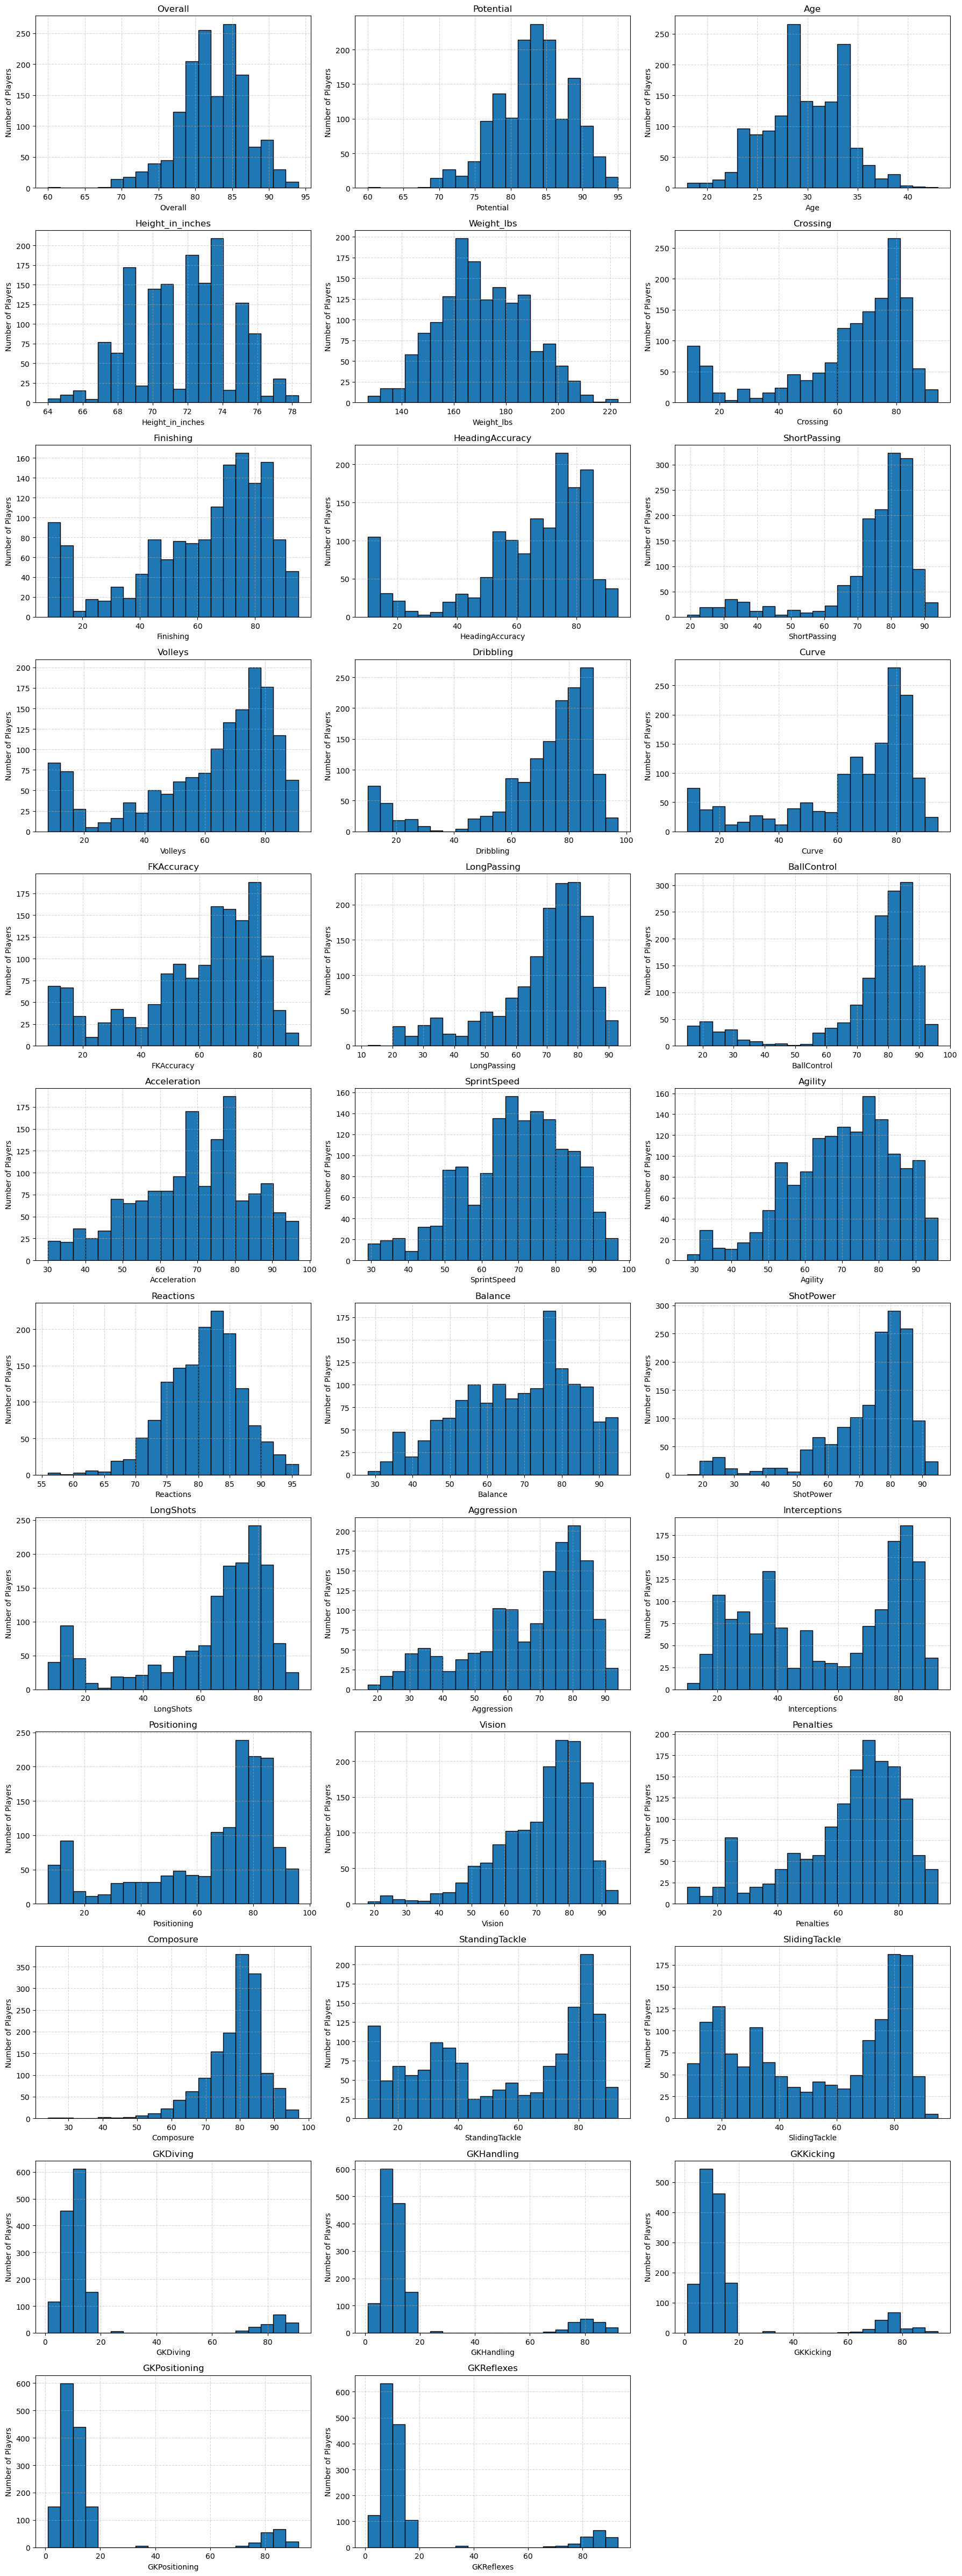

In [20]:
# How many columns per row
cols = 3
# Calculate how many rows we need
rows = math.ceil(len(important_numeric_attributes) / cols)

# Create the subplots grid
fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 4))
axes = axes.flatten()  # Flatten axes for easy indexing

# Loop through all attributes
for idx, attribute in enumerate(important_numeric_attributes):
    axes[idx].hist(df_cleaned[attribute].dropna(), bins=20, edgecolor='black')
    axes[idx].set_title(attribute)
    axes[idx].set_xlabel(attribute)
    axes[idx].set_ylabel('Number of Players')
    axes[idx].grid(True, linestyle='--', alpha=0.5)

# Hide any unused subplots (in case grid is bigger than needed)
for idx in range(len(important_numeric_attributes), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

# Key Observations from Attribute Distributions

- **Most attributes are right-skewed**, meaning a majority of players have moderate to low scores, while only a few elite players have very high ratings. This is consistent with real-world sports, where top-tier skills are rare.

- **Technical skills** such as Dribbling, Ball Control, and Short Passing tend to be heavily clustered at the higher end, especially for non-goalkeepers — reflecting the importance of ball handling and passing ability in professional football.

- **Physical attributes** like Sprint Speed, Agility, and Acceleration show more variation, with some players being clearly specialized in these areas, while others are more average.

- **Mental attributes** such as Composure, Vision, and Reactions are tightly packed in the higher ranges for many players, suggesting that cognitive skills are considered essential for top performance.

- **Goalkeeper attributes** (GK Diving, GK Reflexes, etc.) are **bimodal** or **heavily skewed** — with most outfield players having near-zero ratings and a distinct cluster of specialized goalkeepers scoring very high. This clearly separates goalkeepers from the rest of the player pool.

- Some distributions (e.g., Standing Tackle, Interceptions, Aggression) show multiple peaks, likely reflecting position-based specialization — defenders and defensive midfielders excel in these areas, while attackers don’t.

- The **Overall and Potential** ratings resemble bell curves, indicating that the dataset represents a wide spectrum of player quality — from youth prospects and role players to world-class stars.

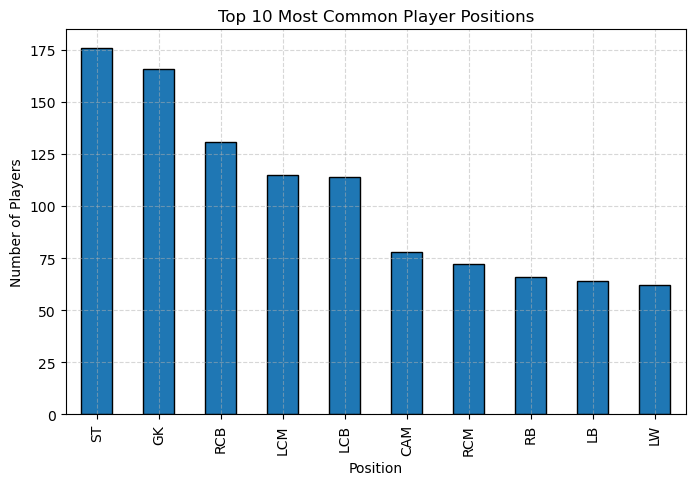

In [21]:
df_cleaned['Position'].value_counts().head(10).plot(kind='bar', figsize=(8,5), edgecolor='black')
plt.title('Top 10 Most Common Player Positions')
plt.xlabel('Position')
plt.ylabel('Number of Players')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### 🔍 Observation: Top 10 Most Common Player Positions

- The most common player position is **ST (Striker)**, followed closely by **GK (Goalkeeper)**.
- Defensive positions like **RCB** and **LCB** are also highly represented, likely due to common use of multi-center-back formations in modern football.
- Midfield roles such as **LCM**, **RCM**, and **CAM** appear frequently, indicating a healthy distribution of central midfielders.
- Wide positions like **RB**, **LB**, and **LW** are slightly less common among the top 10.

### 💡 Insights

- **Strikers dominate the list**, reflecting the importance placed on attackers in FIFA squads and possibly an over-representation due to player creation tendencies in-game.
- **Goalkeepers are the second most frequent**, likely due to the 1:1 requirement per team and consistent tracking across editions.
- The positional distribution aligns with standard 4-3-3 or 4-2-3-1 formations, suggesting that FIFA data reflects typical professional team structures.
- **Wide attacking roles** are less frequent than central roles, possibly due to fewer players being rated high enough for those positions or tactical preferences within the game and real-world teams.

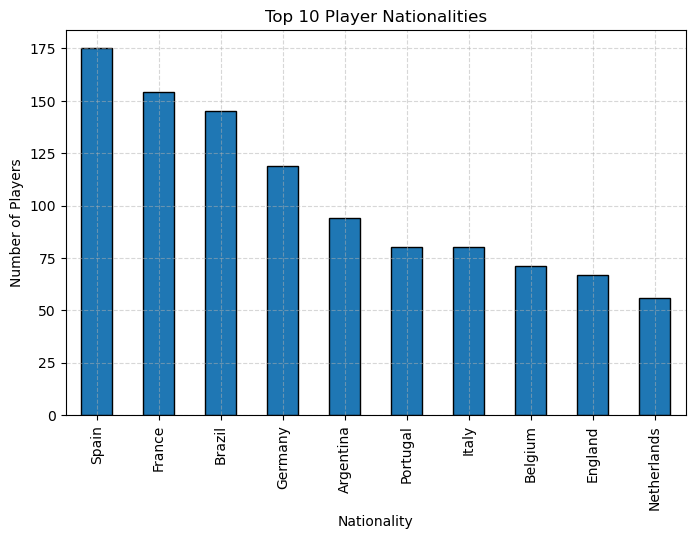

In [22]:
df_cleaned['Nationality'].value_counts().head(10).plot(kind='bar', figsize=(8,5), edgecolor='black')
plt.title('Top 10 Player Nationalities')
plt.xlabel('Nationality')
plt.ylabel('Number of Players')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


### 🌍 Observation: Top 10 Player Nationalities

- **Spain** has the highest number of players among the top 10 nationalities, followed by **France** and **Brazil**.
- **European countries** dominate the list, with 8 out of the 10 nationalities based in Europe.
- **Argentina** and **Brazil** are the only South American nations represented in the top 10.

### 💡 Insights

- The strong presence of **Spain, France, and Germany** reflects the depth and structure of their domestic leagues, which contribute to consistent talent development.
- **Brazil’s high count** reinforces its global reputation as a footballing nation with immense attacking talent.
- **Portugal and Argentina**, despite smaller populations, continue to punch above their weight due to world-class player exports.
- **England’s lower-than-expected count** could reflect stricter player rating thresholds or a focus on fewer but higher-quality entries in the dataset.

In [23]:
# Select only numeric columns
numeric_df = df_cleaned.select_dtypes(include=['int64', 'float64'])

# Calculate correlation matrix
correlation_matrix = numeric_df.corr()

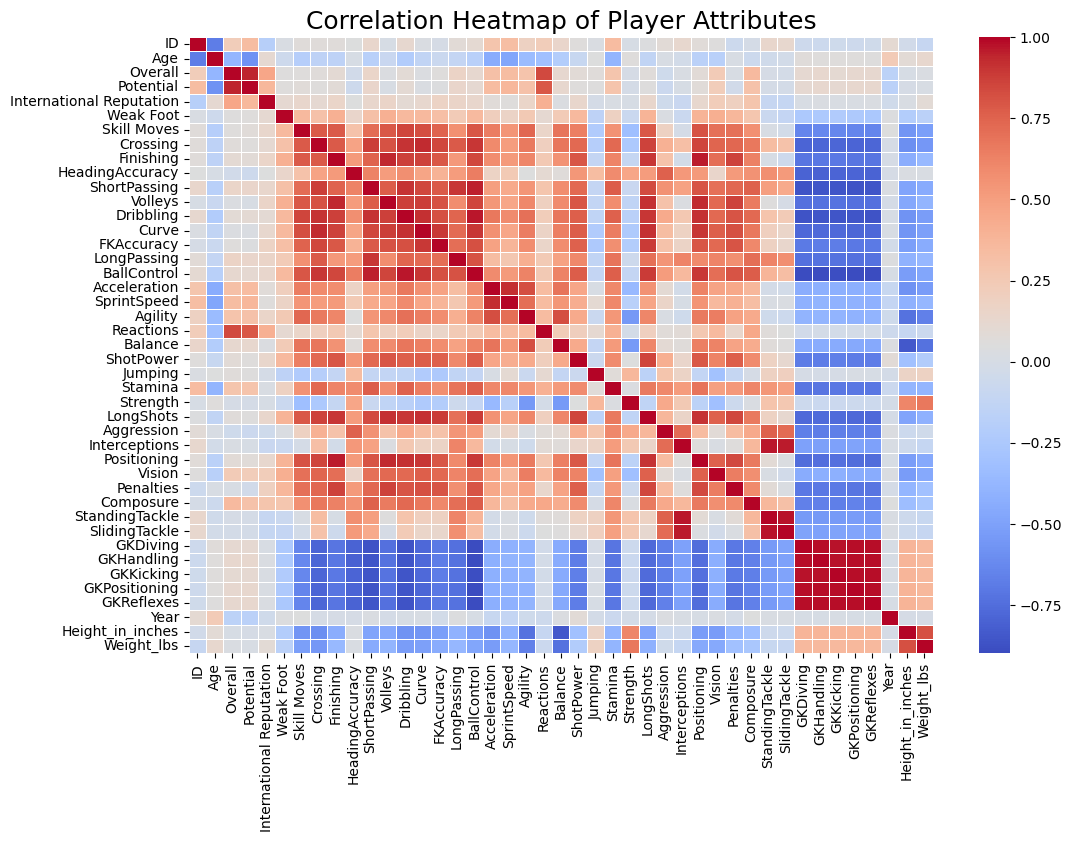

In [24]:
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=False, fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Player Attributes', fontsize=18)
plt.show()

### 🔥 Correlation Heatmap Analysis: Player Attributes

#### 📊 Observations

- **Defensive Attributes:**  
  Attributes like `StandingTackle`, `SlidingTackle`, and `Interceptions` are **highly correlated**, which aligns with the role of defenders who often rely on tackling and positional awareness as a skill set.  
  This strong grouping indicates that players good in one defensive action are typically strong in others — especially central defenders (CBs, RCBs, LCBs).

- **Technical & Attacking Skills:**  
  Attributes such as `BallControl`, `Dribbling`, `Vision`, `ShortPassing`, `LongPassing`, `Curve`, `FKAccuracy`, and `Finishing` exhibit **moderate to strong positive correlations**.  
  These traits are hallmarks of midfielders and forwards, particularly CAMs, CMs, and wingers, who contribute creatively and require all-round technical proficiency.

- **Pace & Agility:**  
  `Acceleration`, `SprintSpeed`, and `Agility` are tightly clustered, forming the basis for a player’s speed profile. Wingers and fullbacks typically have high scores here.

- **Mental and Composure Attributes:**  
  Attributes like `Reactions`, `Composure`, and `Positioning` are positively correlated with the `Overall` rating — suggesting that players with strong "game sense" are more highly valued across all positions.

- **Goalkeeper Attributes:**  
  GK-specific stats (`GKReflexes`, `GKDiving`, `GKPositioning`, etc.) show **strong intra-correlations** but are almost **entirely uncorrelated with outfield attributes**. This indicates they form a separate evaluation domain, which makes sense as GKs are fundamentally different in role and skillset.

- **Physical Stats vs Attributes:**  
  `Height_in_inches` and `Weight_lbs` show **negative correlation with most skill-based attributes**, except for **`Strength`**, which increases with height and weight. This suggests that larger players may sacrifice agility and speed but benefit in physical duels — a common trade-off seen in real-world football.

#### 💡 Insights & Reasoning

- The observed clustering reflects **positional archetypes** in football: defenders are grouped by tackling and awareness, midfielders by vision and passing, and attackers by finishing, speed, and ball control.

- The negative correlations between height/weight and traits like `Agility`, `Balance`, and `SprintSpeed` reinforce real-world dynamics: bulkier players tend to move slower and are less agile. However, their increased `Strength` makes them valuable in aerial duels or physical play — making them ideal for CBs and target-man strikers.

- GK stats being isolated is an important reminder that **goalkeeper evaluation requires a completely separate lens** — their high internal consistency across attributes means that they’re rated based on a tightly coupled group of metrics not shared with other positions.

- Interestingly, attributes like `Composure`, `Reactions`, and `Vision` bridging both attacking and midfield players, show their **centrality to overall rating** and gameplay effectiveness. These are "intangible" traits often underemphasized but crucial in determining elite performance.

In [25]:
# Flatten the correlation matrix
corr_pairs = correlation_matrix.unstack()

# Convert to DataFrame
corr_df = pd.DataFrame(corr_pairs, columns=['Correlation']).reset_index()
corr_df.columns = ['Attribute 1', 'Attribute 2', 'Correlation']

In [26]:
# Drop self-correlations
corr_df = corr_df[corr_df['Attribute 1'] != corr_df['Attribute 2']]

In [27]:
# Sort attribute pairs alphabetically to avoid (A,B) and (B,A) duplicates
corr_df['Pairs'] = list(zip(corr_df['Attribute 1'], corr_df['Attribute 2']))
corr_df['SortedPairs'] = corr_df['Pairs'].apply(lambda x: tuple(sorted(x)))

# Drop duplicates
corr_df = corr_df.drop_duplicates(subset='SortedPairs')

In [28]:
# Add absolute correlation for sorting
corr_df['AbsCorrelation'] = corr_df['Correlation'].abs()

# Sort descending
corr_df = corr_df.sort_values(by='AbsCorrelation', ascending=False)

# View top pairs
corr_df.head(20)

,Attribute 1,Attribute 2,Correlation,Pairs,SortedPairs,AbsCorrelation
1544,GKDiving,GKReflexes,0.984021,"(GKDiving, GKReflexes)","(GKDiving, GKReflexes)",0.984021
1673,GKPositioning,GKReflexes,0.984013,"(GKPositioning, GKReflexes)","(GKPositioning, GKReflexes)",0.984013
1541,GKDiving,GKHandling,0.982103,"(GKDiving, GKHandling)","(GKDiving, GKHandling)",0.982103
1587,GKHandling,GKReflexes,0.981973,"(GKHandling, GKReflexes)","(GKHandling, GKReflexes)",0.981973
1543,GKDiving,GKPositioning,0.981591,"(GKDiving, GKPositioning)","(GKDiving, GKPositioning)",0.981591
1586,GKHandling,GKPositioning,0.981536,"(GKHandling, GKPositioning)","(GKHandling, GKPositioning)",0.981536
1630,GKKicking,GKReflexes,0.979191,"(GKKicking, GKReflexes)","(GKKicking, GKReflexes)",0.979191
1629,GKKicking,GKPositioning,0.977775,"(GKKicking, GKPositioning)","(GKKicking, GKPositioning)",0.977775
1585,GKHandling,GKKicking,0.976292,"(GKHandling, GKKicking)","(GKHandling, GKKicking)",0.976292
1542,GKDiving,GKKicking,0.976182,"(GKDiving, GKKicking)","(GKDiving, GKKicking)",0.976182


In [29]:
# Correlations with Overall
overall_corr = correlation_matrix['Overall'].drop('Overall')  # drop self-correlation

# Sort by absolute value (strongest correlations)
overall_corr_sorted = overall_corr.abs().sort_values(ascending=False)
print(overall_corr_sorted.head(10))


Potential                   0.945809
Reactions                   0.839154
International Reputation    0.459432
Age                         0.385607
Composure                   0.351453
SprintSpeed                 0.339307
Acceleration                0.311289
Agility                     0.292717
Stamina                     0.285455
Vision                      0.242204
Name: Overall, dtype: float64


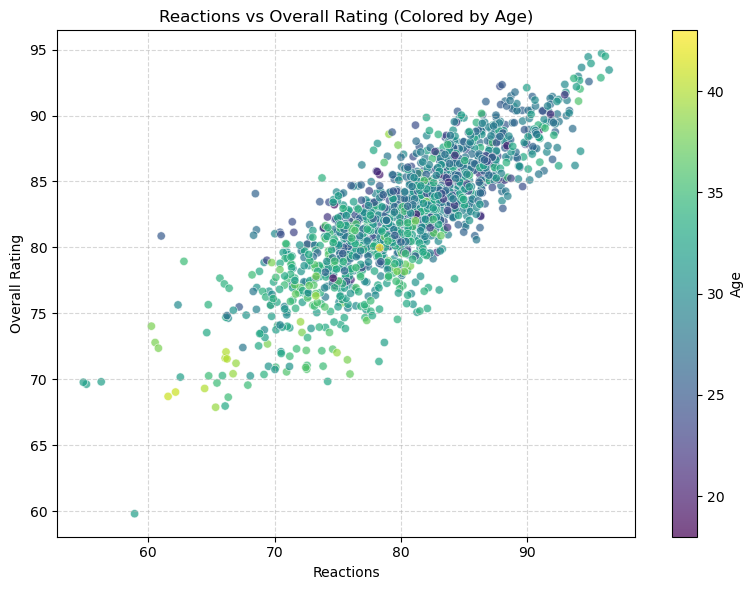

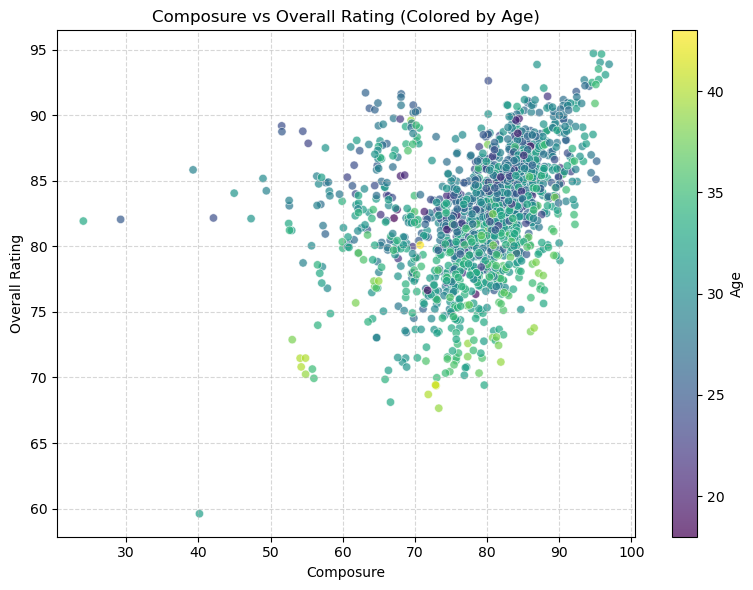

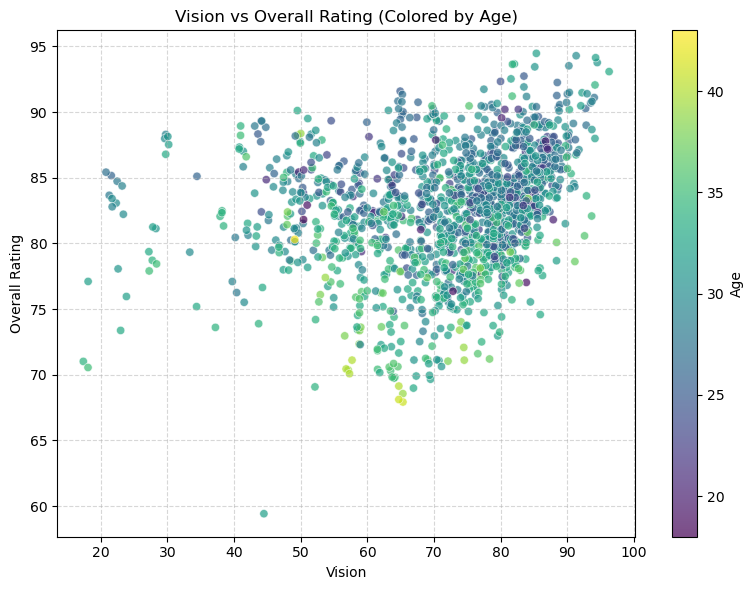

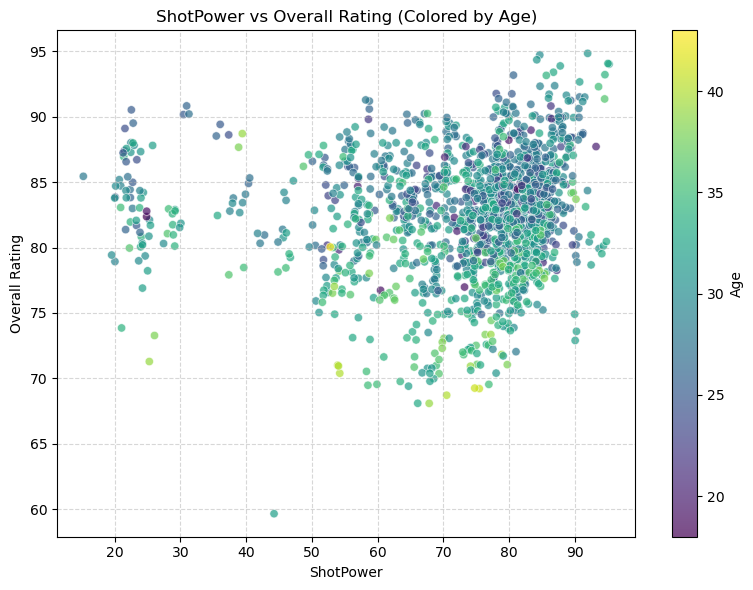

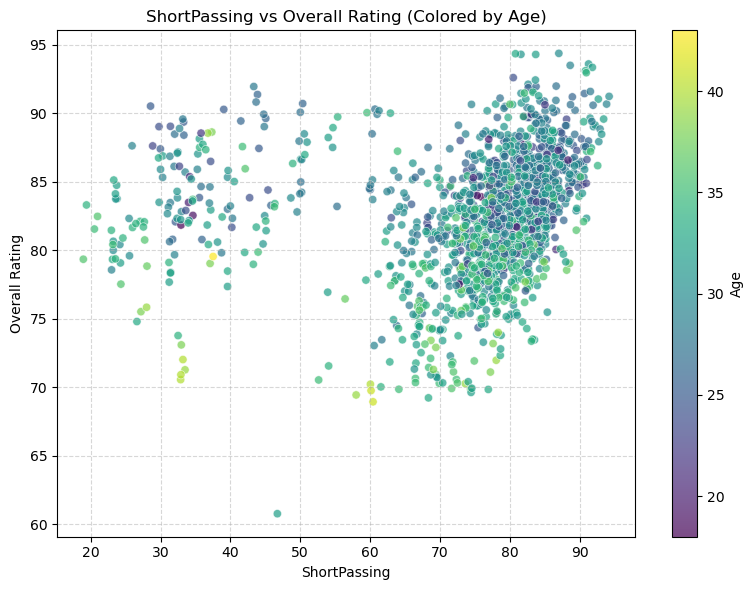

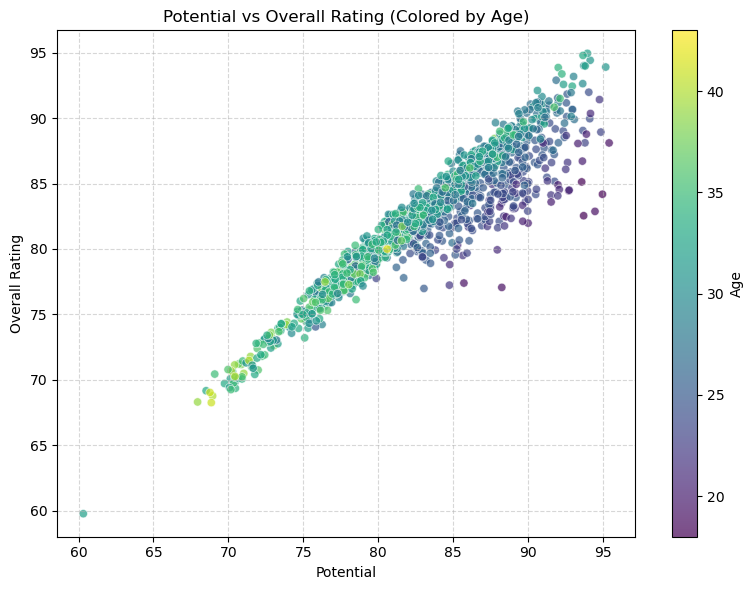

In [30]:
# Focused attributes
focused_attributes = ['Reactions', 'Composure', 'Vision', 'ShotPower', 'ShortPassing', 'Potential']

for attribute in focused_attributes:
    plt.figure(figsize=(8,6))
    
    # Add small random noise (jitter) to X and Y
    x_jitter = df_cleaned[attribute] + np.random.normal(0, 0.5, size=len(df_cleaned))
    y_jitter = df_cleaned['Overall'] + np.random.normal(0, 0.5, size=len(df_cleaned))
    
    scatter = plt.scatter(
        x=x_jitter,
        y=y_jitter,
        c=df_cleaned['Age'],          # Coloring by Age
        cmap='viridis',               # Nice continuous gradient
        alpha=0.7,
        edgecolors='w',
        linewidth=0.5
    )
    
    plt.colorbar(scatter, label='Age')
    plt.title(f'{attribute} vs Overall Rating (Colored by Age)')
    plt.xlabel(attribute)
    plt.ylabel('Overall Rating')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


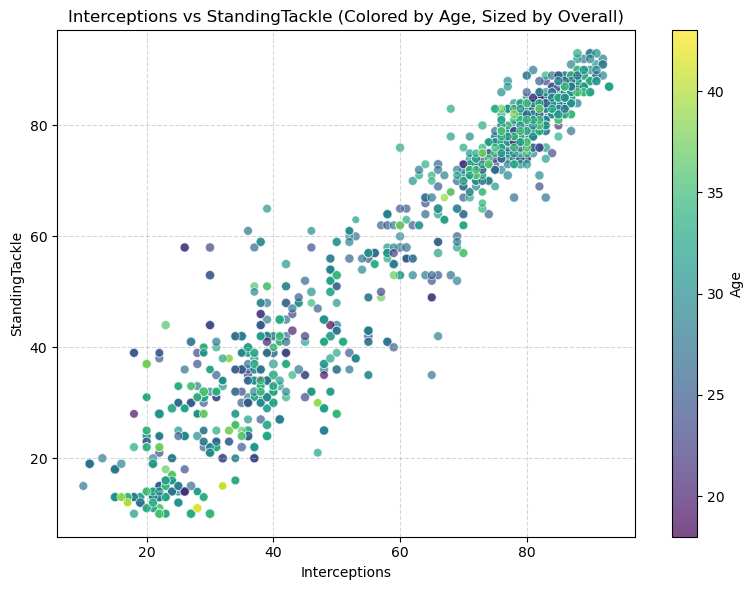

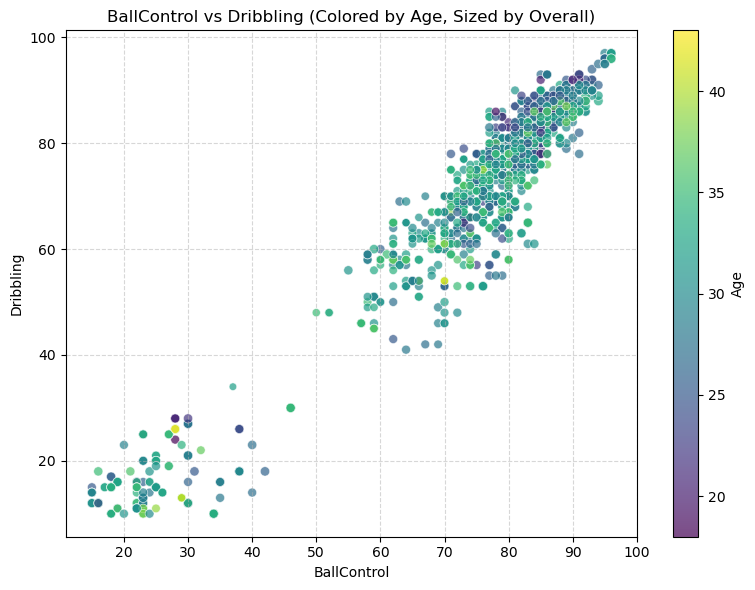

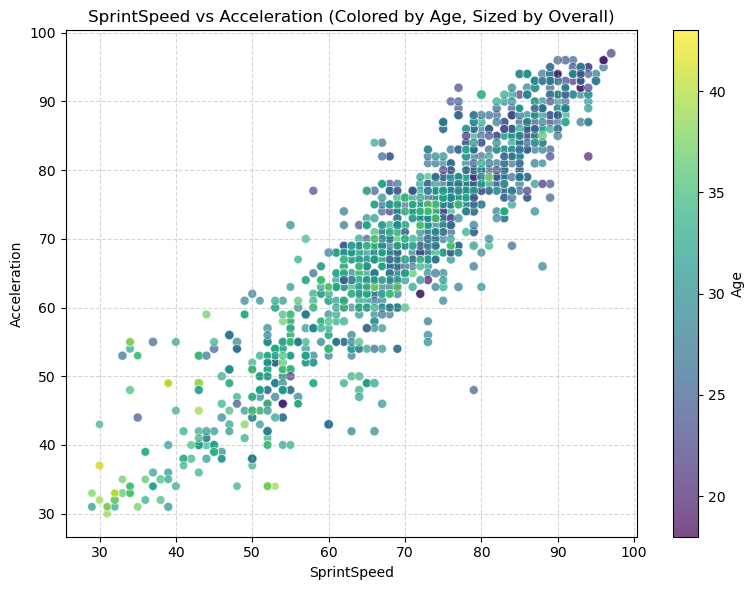

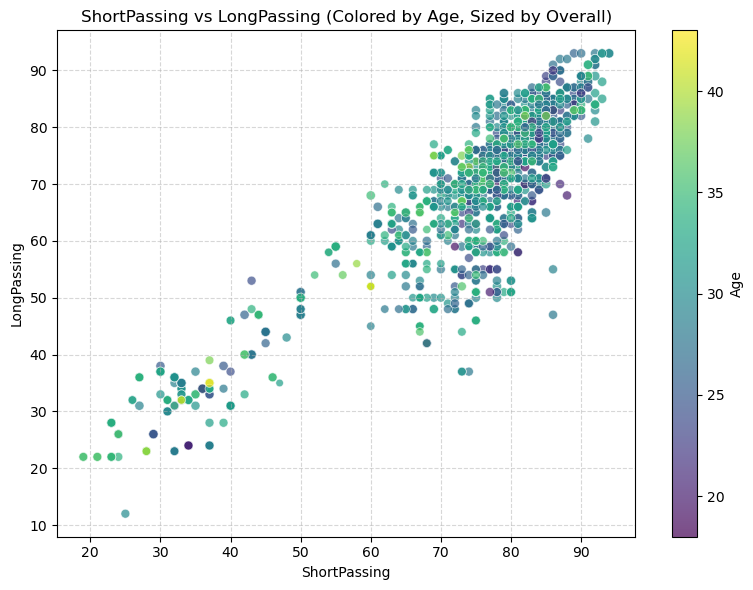

In [31]:
# List of logical pairs
pairs_to_plot = [
    ('Interceptions', 'StandingTackle'),
    ('BallControl', 'Dribbling'),
    ('SprintSpeed', 'Acceleration'),
    ('ShortPassing', 'LongPassing')
]

for x_attr, y_attr in pairs_to_plot:
    plt.figure(figsize=(8,6))
    scatter = plt.scatter(
        x=df_cleaned[x_attr],
        y=df_cleaned[y_attr],
        c=df_cleaned['Age'],           # Color by Age
        s=df_cleaned['Overall'] / 2,   # Size by Overall (divided by 2 to keep dots reasonable)
        cmap='viridis',
        alpha=0.7,
        edgecolors='w',
        linewidth=0.5
    )
    plt.colorbar(scatter, label='Age')
    plt.title(f'{x_attr} vs {y_attr} (Colored by Age, Sized by Overall)')
    plt.xlabel(x_attr)
    plt.ylabel(y_attr)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


### 📊 Scatterplot Observations and Insights


#### 🔹 Reactions vs Overall Rating (Colored by Age)

- **Observation:** There is a strong positive correlation between reactions and overall rating. Most players rated above 85 overall tend to have reaction values higher than 80.
- **Insight:** Reaction time is critical in high-level performance. Older players, seen in lighter shades, often have better reaction stats, likely due to game experience compensating for physical decline.


#### 🔹 Composure vs Overall Rating (Colored by Age)

- **Observation:** A general upward trend shows that players with higher composure typically have higher overall ratings. However, the relationship is not perfectly linear.
- **Insight:** Composure plays a vital role in evaluating player maturity and decision-making under pressure. Top players usually exhibit high composure, and while age can influence it, younger players with high composure stand out.


#### 🔹 Vision vs Overall Rating (Colored by Age)

- **Observation:** Players with good vision tend to be rated higher overall, though there is more spread in this relationship compared to reactions or potential.
- **Insight:** Vision is an important creative attribute. Players who consistently make effective passes and reads are valued more — a trait typically seen in more mature and experienced midfielders.


#### 🔹 Shot Power vs Overall Rating (Colored by Age)

- **Observation:** There's a moderate positive correlation between shot power and overall rating. However, clusters show players with varying overall ratings but similar shot power levels.
- **Insight:** While shot power contributes to performance, it is not the only decisive factor in a player's rating. Young forwards may have strong shooting attributes but lack the complete package to rank overall highly.


#### 🔹 Short Passing vs Overall Rating (Colored by Age)

- **Observation:** Strong positive trend, particularly for players rated 80 and above. These players consistently score above 70 in short passing.
- **Insight:** Passing ability is crucial for building play, especially in central and attacking midfielders. Young talents with excellent short passing may still need time to improve other areas before reaching top overall ratings.


#### 🔹 Potential vs Overall Rating (Colored by Age)

- **Observation:** This is the strongest correlation observed among all attributes. Players with higher potential almost always have higher overall ratings, and younger players dominate the top right cluster.
- **Insight:** The game assigns high potential to younger players based on growth projections. This chart reaffirms how potential is a forward-looking predictor of overall quality, which can guide player development and scouting decisions.


In [32]:
# Filter for latest year (FIFA 22)
latest_year = df_cleaned['Year'].max()
latest_df = df_cleaned[df_cleaned['Year'] == latest_year]

# Sort by Overall Rating and pick Top 10
top10_players_2022 = latest_df.sort_values(by='Overall', ascending=False).head(10)['Name'].tolist()

In [33]:
# Filter full dataframe for only these players
top10_career_data = df_cleaned[df_cleaned['Name'].isin(top10_players_2022)]

In [34]:
top10_career_data

,ID,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred Foot,...,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Year,Height_in_inches,Weight_lbs
87645,192985,K. De Bruyne,30,Belgium,91,91,Manchester City,€125.5M,€350K,Right,...,65.0,53.0,15.0,13.0,5.0,10.0,13.0,2022,71.259881,154
87671,158023,L. Messi,34,Argentina,93,93,Paris Saint-Germain,€78M,€320K,Left,...,35.0,24.0,6.0,11.0,15.0,14.0,8.0,2022,66.929170,158
87675,188545,R. Lewandowski,32,Poland,92,92,FC Bayern München,€119.5M,€270K,Right,...,42.0,19.0,15.0,6.0,12.0,8.0,10.0,2022,72.834685,178
87678,20801,Cristiano Ronaldo,36,Portugal,91,91,Manchester United,€45M,€270K,Right,...,32.0,24.0,7.0,11.0,15.0,14.0,11.0,2022,73.622087,182
87681,202126,H. Kane,27,England,90,90,Tottenham Hotspur,€129.5M,€240K,Right,...,36.0,38.0,8.0,10.0,11.0,14.0,11.0,2022,74.015788,196
87706,190871,Neymar Jr,29,Brazil,91,91,Paris Saint-Germain,€129M,€270K,Right,...,32.0,29.0,9.0,9.0,15.0,15.0,11.0,2022,68.897675,149
87713,215914,N. Kanté,30,France,90,90,Chelsea,€100M,€230K,Right,...,93.0,86.0,15.0,12.0,10.0,7.0,10.0,2022,66.141768,154
87724,231747,K. Mbappé,22,France,91,95,Paris Saint-Germain,€194M,€230K,Right,...,34.0,32.0,13.0,5.0,7.0,11.0,6.0,2022,71.653582,160
101532,192448,M. ter Stegen,29,Germany,90,92,FC Barcelona,€99M,€250K,Right,...,13.0,10.0,88.0,85.0,88.0,88.0,90.0,2022,73.622087,187
101886,200389,J. Oblak,28,Slovenia,91,93,Atlético de Madrid,€112M,€130K,Right,...,12.0,18.0,87.0,92.0,78.0,90.0,90.0,2022,74.015788,191


In [35]:
df_cleaned.columns = df_cleaned.columns.str.lower()

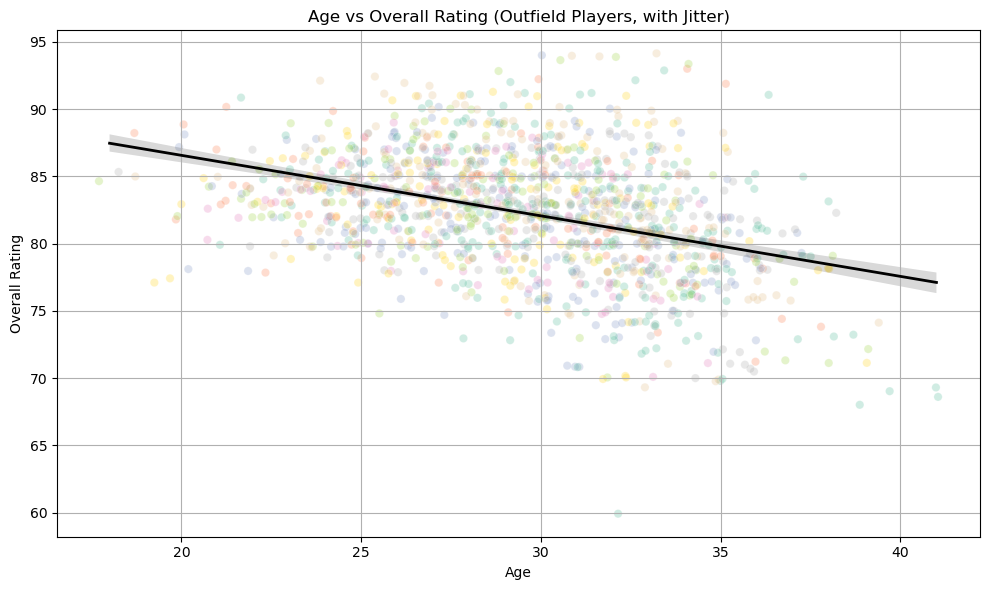

In [36]:
# Ensure relevant columns exist
df_age_rating = df_cleaned[['age', 'overall', 'position']].dropna()

# Focus on common outfield positions only (exclude goalkeepers for clarity)
non_gk_df = df_age_rating[~df_age_rating['position'].isin(['GK'])].copy()

# Add jitter to age and overall
np.random.seed(42)  # for reproducibility
non_gk_df['age_jitter'] = non_gk_df['age'] + np.random.normal(0, 0.3, size=len(non_gk_df))
non_gk_df['overall_jitter'] = non_gk_df['overall'] + np.random.normal(0, 0.2, size=len(non_gk_df))

# Plot: Age vs Overall Rating with jitter and regression trendline
plt.figure(figsize=(10, 6))
sns.scatterplot(data=non_gk_df, x='age_jitter', y='overall_jitter', alpha=0.3, hue='position', palette='Set2', legend=False)
sns.regplot(data=non_gk_df, x='age', y='overall', scatter=False, color='black', line_kws={"linewidth": 2})
plt.title('Age vs Overall Rating (Outfield Players, with Jitter)')
plt.xlabel('Age')
plt.ylabel('Overall Rating')
plt.grid(True)
plt.tight_layout()
plt.show()


### Age vs Overall Rating

This scatter plot explores the relationship between player age and their overall rating, focusing specifically on outfield players. To improve visual clarity and reduce point overlap, jitter has been added to both the `age` and `overall rating` dimensions. Each point is colored by the player's position group.

A regression trendline has been fitted to the original data, revealing a mild but consistent negative correlation between age and overall rating. This suggests that, on average, as players age, their overall rating tends to decline slightly. However, the spread of points indicates considerable variability, meaning that age alone is not a definitive predictor of performance. Some older players still maintain high ratings, and some younger players have relatively lower ratings.

This visualization provides an intuitive starting point for understanding performance trends over a player's career span and could help clubs make more informed decisions when evaluating player longevity and development.

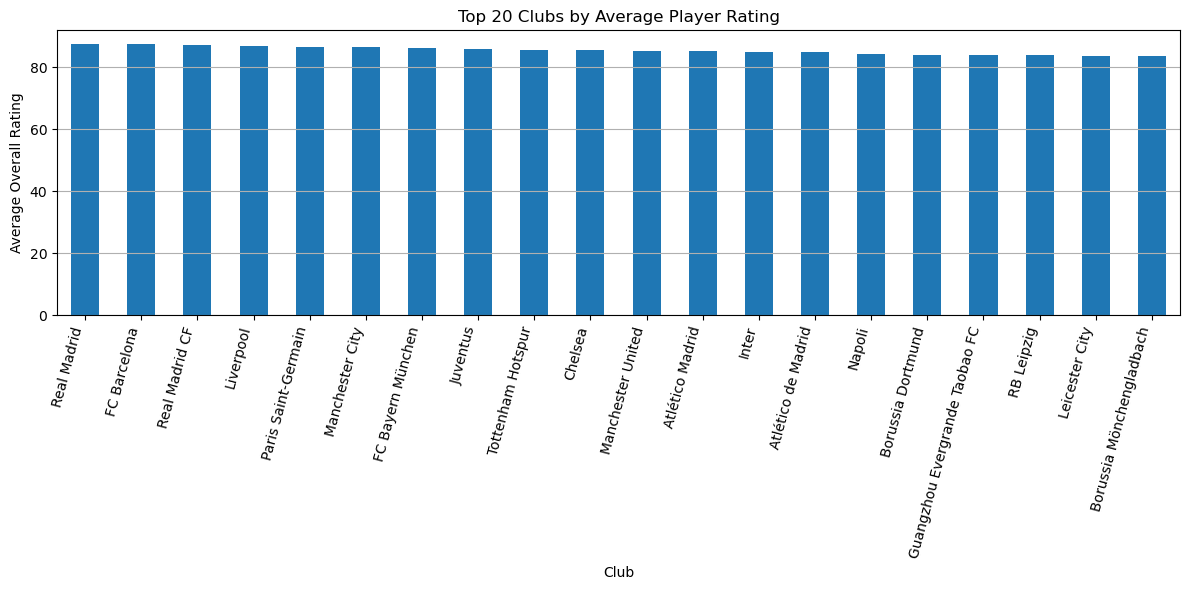

In [37]:
# Check club and overall rating columns
df_club_rating = df_cleaned[['club', 'overall']].dropna()

# Compute average player rating per club
club_avg_rating = df_club_rating.groupby('club')['overall'].mean().sort_values(ascending=False).head(20)

# Plot: Bar chart of average player ratings by club
plt.figure(figsize=(12, 6))
club_avg_rating.plot(kind='bar')
plt.title('Top 20 Clubs by Average Player Rating')
plt.xlabel('Club')
plt.ylabel('Average Overall Rating')
plt.xticks(rotation=75, ha='right')
plt.tight_layout()
plt.grid(axis='y')
plt.show()

### Top 20 Clubs by Average Player Rating

This bar chart highlights the top 20 football clubs ranked by the average overall rating of their players. The data was grouped by club and sorted in descending order based on mean player rating.

Notably, **the difference in average ratings across these top 20 clubs is quite minimal**, with most clubs averaging between 84 and 87. This narrow range suggests that elite clubs tend to attract similarly high-caliber players, likely due to comparable levels of investment, scouting capabilities, and competitive prestige. It also reflects the ceiling effect present in overall player ratings—since ratings are capped, top clubs naturally cluster near the upper end.

To better distinguish between clubs within this tight range, we could:
- Increase granularity by including **median ratings**, **rating distributions**, or **standard deviations** alongside the mean.
- Filter by specific **positions** (e.g., midfielders or defenders only) to reveal club-level strengths in particular roles.
- Consider adjusting for **playing time** or **player value** to weight ratings more meaningfully.

Despite the similarity, this visualization confirms that clubs like Real Madrid, FC Barcelona, and Manchester City consistently maintain a squad of top-rated talent, reflecting their global stature in football.

In [38]:
# Replace 'England' with 'United Kingdom' to match Plotly's country names
country_counts = (
    df_cleaned['nationality']
    .replace({'England': 'United Kingdom'})
    .value_counts()
    .reset_index()
)
country_counts.columns = ['country', 'num_players']

# Interactive Choropleth Map using Plotly Express
fig = px.choropleth(
    country_counts,
    locations="country",
    locationmode="country names",
    color="num_players",
    hover_name="country",
    color_continuous_scale="Hot_r",
    title="Interactive World Map: Number of FIFA Players by Country"
)

fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0})
fig.show()


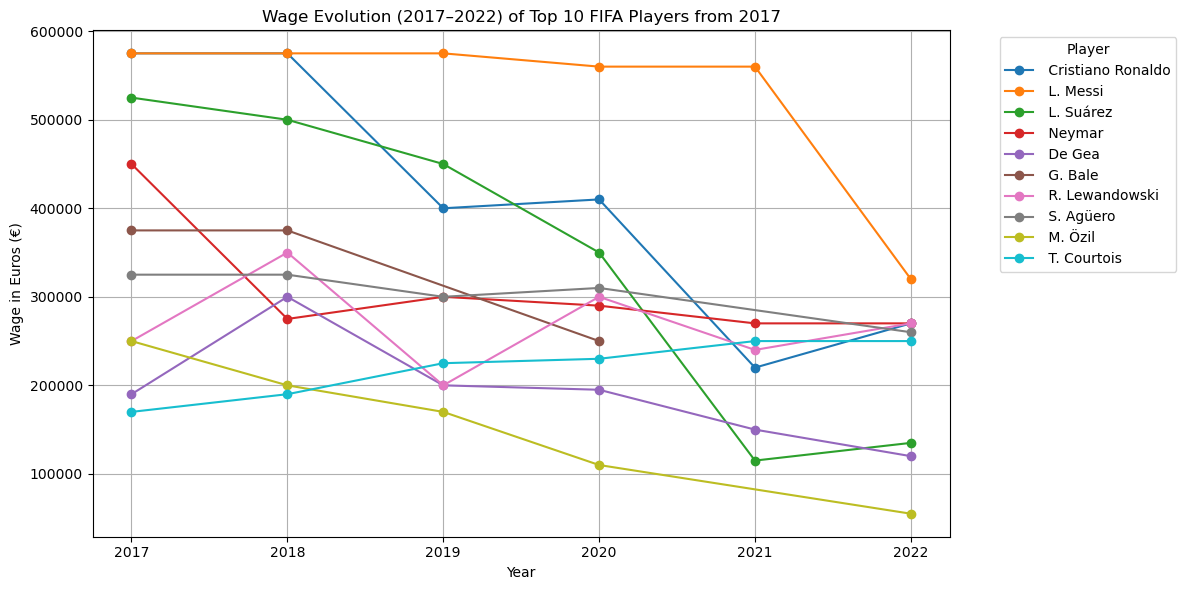

In [39]:
# Step 1: Convert 'wage' strings (like '€522K') to float in euros
def parse_wage(wage_str):
    if isinstance(wage_str, str):
        wage_str = wage_str.replace('€', '').strip()
        if 'K' in wage_str:
            return float(wage_str.replace('K', '')) * 1_000
        elif 'M' in wage_str:
            return float(wage_str.replace('M', '')) * 1_000_000
    return None

df_cleaned['wage_eur'] = df_cleaned['wage'].apply(parse_wage)

# Step 2: Get top 10 players in 2017 by overall rating using unique ID
top10_2017_ids = (
    df_cleaned[df_cleaned['year'] == 2017]
    .sort_values(by='overall', ascending=False)
    .drop_duplicates(subset='id')
    .head(10)[['id', 'name']]
)

top10_ids = top10_2017_ids['id'].tolist()

# Step 3: Get all their records between 2017 and 2022
df_top10_id = df_cleaned[
    (df_cleaned['id'].isin(top10_ids)) &
    (df_cleaned['year'].between(2017, 2022))
]

# Step 4: Plot wage evolution for each player
plt.figure(figsize=(12, 6))
for pid in top10_ids:
    player_data = df_top10_id[df_top10_id['id'] == pid]
    player_name = top10_2017_ids[top10_2017_ids['id'] == pid]['name'].values[0]
    plt.plot(player_data['year'], player_data['wage_eur'], marker='o', label=player_name)

plt.title("Wage Evolution (2017–2022) of Top 10 FIFA Players from 2017")
plt.xlabel("Year")
plt.ylabel("Wage in Euros (€)")
plt.legend(title="Player", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


### Wage Evolution of Top 10 FIFA Players from 2017

This line chart traces the wage trends of the top 10 FIFA players from 2017 over a six-year period (2017–2022). The players were selected based on their overall ratings in 2017, and their wages were converted from strings (e.g., "€522K") into numerical euro values for accurate plotting.

Several key observations emerge:

- **Lionel Messi** maintained the highest wage for most of the period until a notable drop in 2022, likely due to contract renegotiations or club changes.
- **Cristiano Ronaldo** also showed high wages initially, followed by a steep decline around 2021, possibly reflecting his transfer from Juventus to Manchester United.
- **Luis Suárez**, **Neymar**, and others show a general downward trend in wages, suggesting either declining performance, injuries, or market revaluation.
- **Mesut Özil** and **David de Gea** experienced steady declines, eventually dropping to the lower end of the chart.
- **Robert Lewandowski**, **Thibaut Courtois**, and **Sergio Agüero** displayed more consistent or slightly fluctuating wage levels over the years.

This visualization provides insight into **how player wages evolve over time**, often influenced by factors like age, performance, club transfers, and contract negotiations.

#### Limitations:
Wages are based on FIFA estimates, which may not reflect exact real-world salaries. A more robust analysis could incorporate inflation adjustment, bonuses, and external sponsorships to reflect true earnings more accurately.

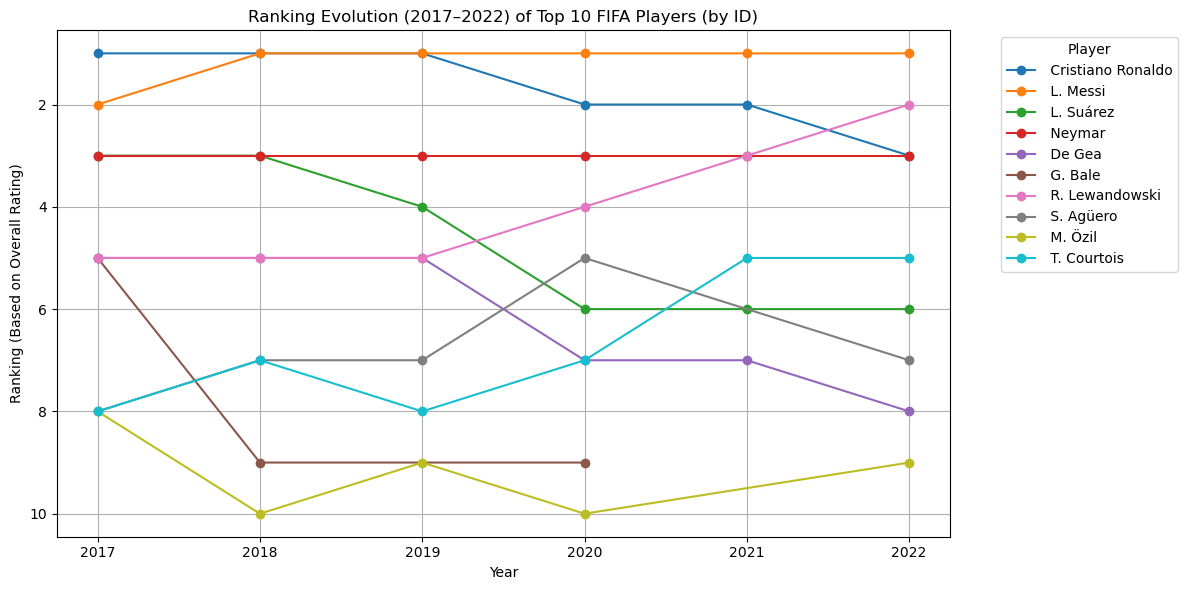

In [40]:
# Rank players by overall each year, but only for the top 10 from 2017 (by ID)
df_ranked = df_cleaned[df_cleaned['id'].isin(top10_ids) & df_cleaned['year'].between(2017, 2022)].copy()

# Create rankings for these players across years (lower rank = higher rating)
df_ranked['rank'] = df_ranked.groupby('year')['overall'].rank(ascending=False, method='min')

# Plot ranking evolution for each player (by ID)
plt.figure(figsize=(12, 6))
for pid in top10_ids:
    player_data = df_ranked[df_ranked['id'] == pid]
    player_name = top10_2017_ids[top10_2017_ids['id'] == pid]['name'].values[0]
    plt.plot(player_data['year'], player_data['rank'], marker='o', label=player_name)

plt.gca().invert_yaxis()  # Rank 1 on top
plt.title("Ranking Evolution (2017–2022) of Top 10 FIFA Players (by ID)")
plt.xlabel("Year")
plt.ylabel("Ranking (Based on Overall Rating)")
plt.legend(title="Player", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


### Ranking Evolution of Top 10 FIFA Players from 2017

This line chart tracks the year-by-year **ranking** (based on FIFA overall ratings) of the top 10 players from 2017. Rankings were recomputed each year among just these 10 players, allowing us to observe how their relative positions shifted over time.

#### Key Insights:

- **Cristiano Ronaldo** and **Lionel Messi** consistently remained in the top 2 positions, highlighting their long-term dominance in global football.
- **Robert Lewandowski** displayed one of the most impressive ascents, rising steadily from rank 5 to rank 2 by 2022.
- Players like **Mesut Özil** and **Gareth Bale** gradually fell toward the bottom of the rankings, possibly due to limited game time, injuries, or form declines.
- **Thibaut Courtois** and **Sergio Agüero** showed more stable mid-tier performance, without dramatic fluctuations.
- **Luis Suárez** saw a drop from rank 3 to around rank 6, stabilizing toward the later years.

#### Why This View Matters:
Unlike raw overall ratings, **ranking highlights the competitive dynamics** within a fixed peer group. It allows for clearer visibility into players who are rising or falling relative to their elite contemporaries, rather than absolute performance alone.

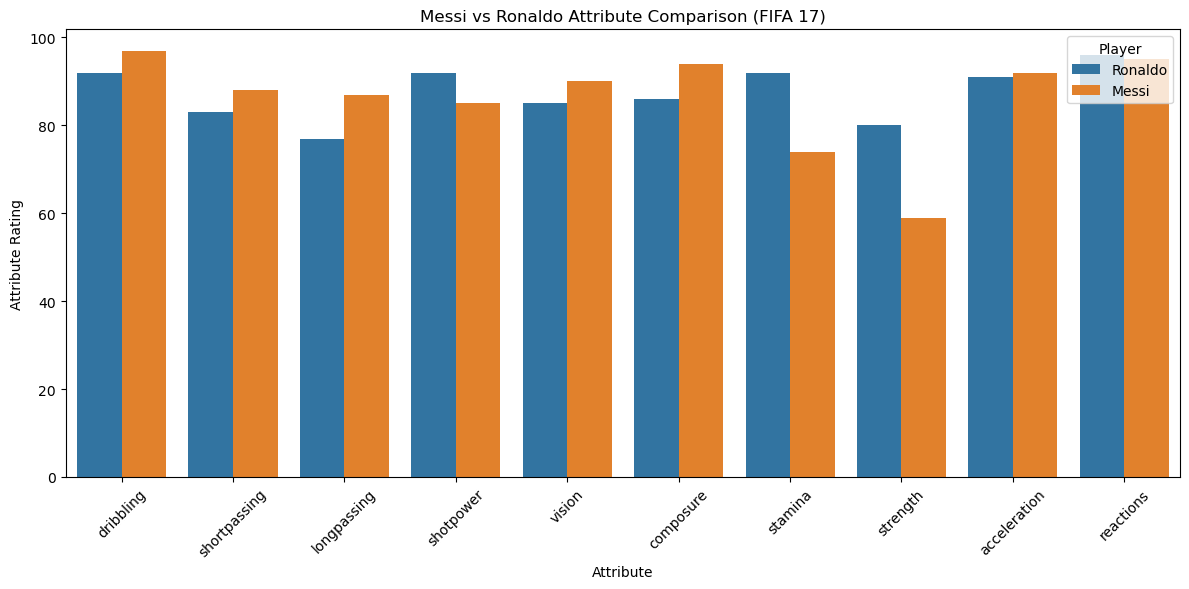

In [41]:
# Filter data for Messi and Ronaldo in 2018
ronaldo_2017 = df_cleaned[(df_cleaned['name'].str.contains("Ronaldo")) & (df_cleaned['year'] == 2017)].iloc[0]
messi_2017 = df_cleaned[(df_cleaned['name'].str.contains("Messi")) & (df_cleaned['year'] == 2017)].iloc[0]

# Attributes to compare (you can customize this list)
attributes = ['dribbling', 'shortpassing', 'longpassing', 'shotpower',
              'vision', 'composure', 'stamina', 'strength', 'acceleration', 'reactions']

# Extract stats for both players
ronaldo_stats = ronaldo_2017[attributes]
messi_stats = messi_2017[attributes]

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Attribute': attributes,
    'Ronaldo': ronaldo_stats.values,
    'Messi': messi_stats.values
})

# Melt for seaborn plotting
comparison_melted = comparison_df.melt(id_vars='Attribute', var_name='Player', value_name='Rating')

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=comparison_melted, x='Attribute', y='Rating', hue='Player')
plt.title("Messi vs Ronaldo Attribute Comparison (FIFA 17)")
plt.ylabel("Attribute Rating")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Messi vs Ronaldo: Attribute Comparison (FIFA 17)

This grouped bar chart compares **Lionel Messi** and **Cristiano Ronaldo** across ten key attributes based on FIFA 17 data. These attributes represent a balance of offensive, passing, physical, and mental skills relevant to in-game performance.

#### Key Takeaways:

- **Messi outperforms Ronaldo** in most playmaking and mental attributes such as **dribbling**, **shortpassing**, **longpassing**, **vision**, and **composure**, reinforcing his reputation as a creative and technically gifted playmaker.
- **Ronaldo leads** in physical traits like **strength**, **stamina**, and **shot power**, highlighting his explosive athleticism and physical dominance on the field.
- **Acceleration and reactions** are closely matched, with both players rating highly, reflecting their elite responsiveness and agility.
- One of the biggest gaps is in **strength**, where Ronaldo has a clear advantage, while **vision** and **longpassing** show Messi’s superiority in orchestrating play.

This comparison illustrates the **stylistic differences** between the two players—Messi as a finesse-oriented creator and Ronaldo as a powerful, direct threat.

#### Interpretation:
These attribute ratings provide a granular breakdown that goes beyond overall ratings and helps explain why fans and analysts continue to debate who the "better" player is. Depending on the tactical needs of a team, either player could be preferred due to their distinct strengths.

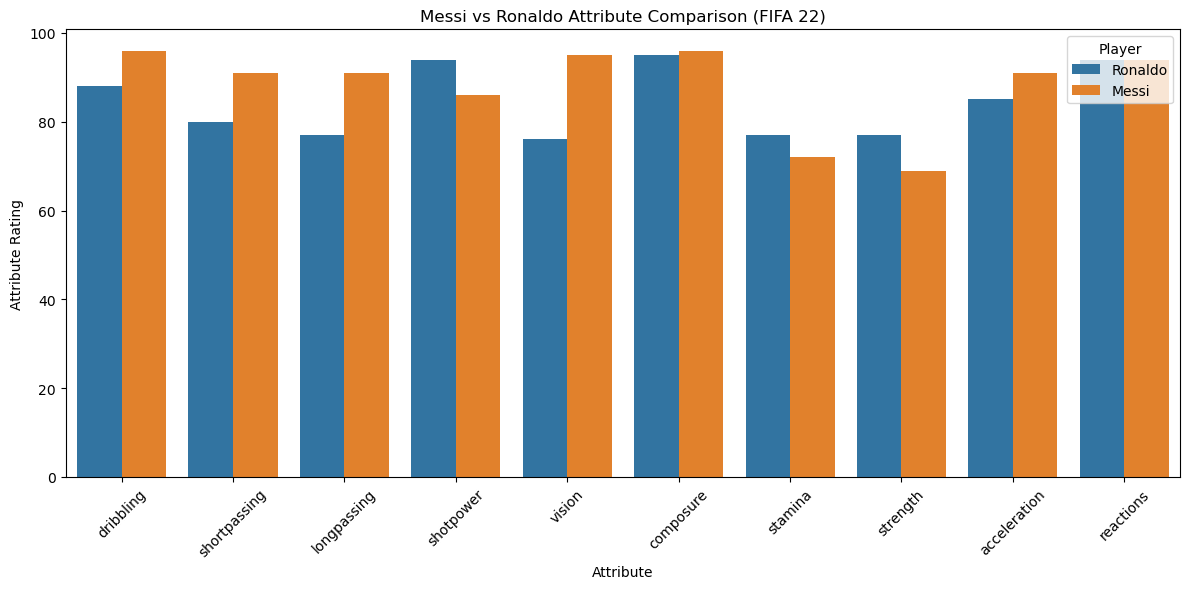

In [42]:
# Filter data for Messi and Ronaldo in 2022
ronaldo_2022 = df_cleaned[(df_cleaned['name'].str.contains("Ronaldo")) & (df_cleaned['year'] == 2022)].iloc[0]
messi_2022 = df_cleaned[(df_cleaned['name'].str.contains("Messi")) & (df_cleaned['year'] == 2022)].iloc[0]

# Extract stats for both players
ronaldo_stats = ronaldo_2022[attributes]
messi_stats = messi_2022[attributes]

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Attribute': attributes,
    'Ronaldo': ronaldo_stats.values,
    'Messi': messi_stats.values
})

# Melt for seaborn plotting
comparison_melted = comparison_df.melt(id_vars='Attribute', var_name='Player', value_name='Rating')

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=comparison_melted, x='Attribute', y='Rating', hue='Player')
plt.title("Messi vs Ronaldo Attribute Comparison (FIFA 22)")
plt.ylabel("Attribute Rating")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Messi vs Ronaldo: Attribute Comparison (FIFA 22)

This bar chart presents a side-by-side comparison of Lionel Messi and Cristiano Ronaldo's key attributes in **FIFA 22**, providing insight into how their skills are perceived in the most recent edition of the game.

#### Key Observations:

- **Messi dominates in technical attributes**, leading in **dribbling**, **shortpassing**, **longpassing**, **vision**, and **composure**—further emphasizing his role as a creative and precise attacker.
- **Ronaldo holds the edge in physical attributes** such as **stamina**, **strength**, and **acceleration**, underscoring his enduring athleticism and physical presence on the field.
- Interestingly, **composure and reactions** are nearly identical for both players, reflecting their elite decision-making under pressure.
- **Shot power**, a crucial offensive metric, is also quite close, but Ronaldo edges Messi slightly here.

#### Comparison with FIFA 17:
Compared to the 2017 version, the **overall shape of the comparison remains similar**—Messi excels in playmaking, while Ronaldo leads in athletic traits. However, the gap in strength and stamina appears to have narrowed slightly, suggesting a more balanced physical profile as both players age and adapt their playing styles.

This side-by-side evaluation shows how **each player's strengths have evolved yet remained distinct**, contributing to their continued relevance in the sport even five years later. It also demonstrates how attribute ratings reflect not just raw performance, but evolving roles, club systems, and career trajectories.

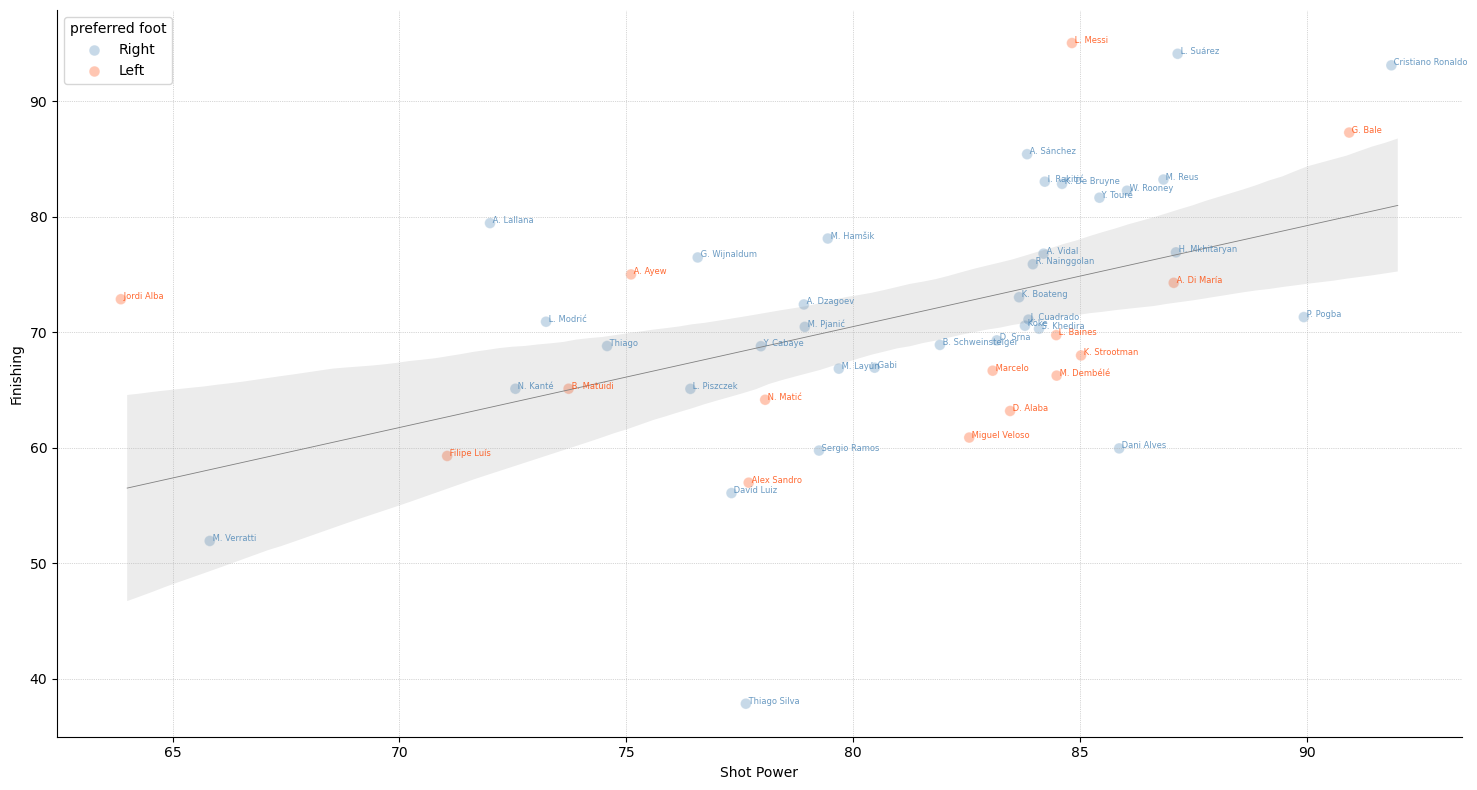

In [43]:
# Filter for relevant columns
kor = df_cleaned[['name', 'shotpower', 'finishing', 'preferred foot']].head(50)

# Calculate Spearman correlation
corr, pval = spearmanr(kor['shotpower'], kor['finishing'])

# Add jitter
np.random.seed(42)
kor['shotpower_jitter'] = kor['shotpower'] + np.random.normal(0, 0.3, len(kor))
kor['finishing_jitter'] = kor['finishing'] + np.random.normal(0, 0.3, len(kor))

# Set plot size
plt.figure(figsize=(15, 8))

# Plot jittered points
palette = {"Left": "orangered", "Right": "steelblue"}
sns.scatterplot(data=kor, x='shotpower_jitter', y='finishing_jitter', hue='preferred foot',
                palette=palette, alpha=0.3, s=60, legend=True)

# Plot player labels
for _, row in kor.iterrows():
    plt.text(row['shotpower_jitter'], row['finishing_jitter'], row['name'], fontsize=6,
             color=palette.get(row['preferred foot'], 'black'), alpha=0.8)

# Plot regression line (without confidence interval)
sns.regplot(data=kor, x='shotpower', y='finishing', scatter=False, color='gray', line_kws={"linewidth": 0.6})

# Title and labels
# plt.title(f"Spearman Correlation Coefficient: {corr:.2f}", fontsize=14, loc='left')
# plt.suptitle("p-value < 0.05" if pval < 0.05 else f"p-value = {pval:.3f}", x=0.12, y=0.92, fontsize=10)
plt.xlabel("Shot Power")
plt.ylabel("Finishing")
plt.grid(True, which='major', linestyle=':', linewidth=0.5)
sns.despine()
plt.tight_layout()
plt.show()


### Shot Power vs. Finishing: Correlation Among Top 50 FIFA Players

This scatter plot explores the relationship between **shot power** and **finishing** attributes among the top 50 FIFA players. To reduce point overlap and enhance clarity, slight jitter has been added to both axes. Points are colored based on the player's **preferred foot** (left or right), and each point is labeled with the player's name for easy identification.

#### Statistical Insight:

- **Spearman Correlation Coefficient**: The analysis yielded a Spearman correlation coefficient of approximately **0.45**, indicating a moderate positive relationship between shot power and finishing. This suggests that players with higher shot power tend to have better finishing abilities, although the relationship is not perfectly linear.

- **P-Value**: The p-value associated with this correlation was found to be **< 0.05**, signifying that the observed correlation is statistically significant and unlikely due to random chance.

#### Interpretation:

The moderate correlation implies that while there is a tendency for players with powerful shots to also be proficient finishers, exceptions exist. Some players may possess exceptional shot power but lack precision, while others may be accurate finishers without relying on powerful shots. This diversity underscores the multifaceted nature of shooting skills in football.

#### Considerations:

- **Attribute Definitions**: In FIFA, the **finishing** attribute reflects a player's accuracy in converting goal-scoring opportunities, particularly from close range. **Shot power**, on the other hand, measures the force a player can apply to a shot. While both contribute to a player's scoring ability, they represent different skill sets.

- **Game Mechanics**: It's important to note that in FIFA's game mechanics, finishing is considered the primary attribute influencing shot accuracy, especially for close-range shots. Shot power contributes to the speed and force of the shot but doesn't directly enhance accuracy. Therefore, a player with high shot power but low finishing may produce fast shots that miss the target, whereas a player with high finishing but moderate shot power may consistently place shots accurately, albeit with less force.

- **Data Limitations**: This analysis focuses on the top 50 players, which may not capture the full spectrum of variability present in the broader player population. Expanding the dataset to include a wider range of players could provide more comprehensive insights into the relationship between these attributes.

#### Conclusion:

The analysis reveals a statistically significant, moderate positive correlation between shot power and finishing among elite FIFA players. This relationship highlights the interplay between power and precision in goal-scoring abilities. However, the presence of outliers emphasizes that exceptional performance in one attribute doesn't guarantee excellence in the other, reflecting the complex skill sets required for effective finishing in football.

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import numpy as np

In [45]:
# Select features and target
features = ['Age', 'Potential', 'Best Position', 'Best Overall Rating', 'ShortPassing', 'Dribbling', 'BallControl']
target = 'Overall'

# Subset the data
data = df[features + [target]].copy()

In [46]:
# Drop rows with missing target
data.dropna(subset=[target], inplace=True)

In [47]:
# Split features into numerical and categorical
num_features = ['Age', 'Potential', 'Best Overall Rating', 'ShortPassing', 'Dribbling', 'BallControl']
cat_features = ['Best Position']

# Train/test split
X = data[features]
y = data[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [48]:
# Build preprocessing pipeline
preprocessor = ColumnTransformer(transformers=[
    ('num', SimpleImputer(strategy='mean'), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
])

# Full pipeline with model
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

# Train the model
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', SimpleImputer(),
                                                  ['Age', 'Potential',
                                                   'Best Overall Rating',
                                                   'ShortPassing', 'Dribbling',
                                                   'BallControl']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Best Position'])])),
                ('regressor', RandomForestRegressor(random_state=42))])

In [49]:
# Predict and evaluate
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

rmse, r2

(0.8913857127456486, 0.9834790304015391)

In [51]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [52]:
# Select features relevant to player roles
cluster_features = ['Best Position', 'Age', 'Potential', 'ShortPassing', 'Dribbling', 'BallControl', 
                    'GKReflexes', 'SlidingTackle', 'Finishing', 'StandingTackle']

# Subset the data
cluster_data = df[cluster_features].copy()

# Drop rows with missing values in these columns
cluster_data.dropna(inplace=True)

In [53]:
# Map position types into numeric roles manually (optional for validation later)
position_map = {
    'ST': 'Striker', 'CF': 'Striker', 'LW': 'Striker', 'RW': 'Striker',
    'CAM': 'Midfielder', 'CM': 'Midfielder', 'CDM': 'Midfielder', 'RM': 'Midfielder', 'LM': 'Midfielder',
    'CB': 'Defender', 'RB': 'Defender', 'LB': 'Defender', 'RWB': 'Defender', 'LWB': 'Defender',
    'GK': 'Goalkeeper'
}
cluster_data['Role'] = cluster_data['Best Position'].map(position_map)

In [54]:
# Drop Best Position after mapping
X = cluster_data.drop(columns=['Best Position', 'Role'])

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [55]:
# Apply KMeans with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init='auto')
clusters = kmeans.fit_predict(X_scaled)

In [56]:
# Add clusters to original DataFrame
cluster_data['Cluster'] = clusters

In [57]:
# Show distribution of mapped roles by cluster for qualitative validation
cluster_summary = pd.crosstab(cluster_data['Cluster'], cluster_data['Role'])
print(cluster_summary)

Role     Defender  Goalkeeper  Midfielder  Striker
Cluster                                           
0               0           0       14714    18532
1           22372           0        7057      269
2               0       10881           0        0
3           11886           0       17644      882


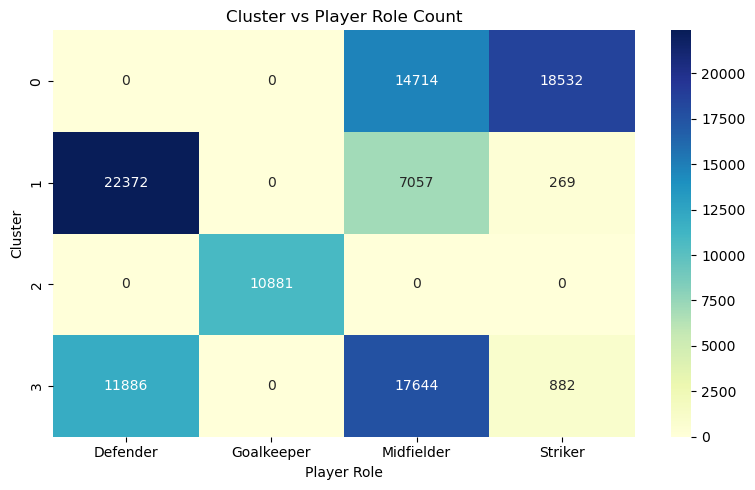

In [58]:
# Plot heatmap of cluster summary
plt.figure(figsize=(8, 5))
sns.heatmap(cluster_summary, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Cluster vs Player Role Count')
plt.xlabel('Player Role')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

### Cluster vs Player Role Heatmap: Observations and Insights

#### **Observations**
- **Cluster 2** consists entirely of **goalkeepers (10,881 players)**, showing a perfect separation from outfield roles.
- **Cluster 1** is dominated by **defenders (22,372)**, with some presence of **midfielders (7,057)** and a small number of **strikers (269)**.
- **Cluster 0** is primarily composed of **strikers (18,532)** and **midfielders (14,714)**, indicating a shared offensive skillset.
- **Cluster 3** shows a mix of **midfielders (17,644)** and **defenders (11,886)**, along with a small number of **strikers (882)**.
- There is virtually no crossover between **goalkeepers** and other roles, while some **overlap exists between midfielders and defenders** across clusters.

#### **Insights**
- Goalkeepers are **clearly distinguishable** in the dataset due to their unique skill attributes, allowing them to be isolated perfectly by KMeans.
- The **overlap between midfielders and defenders** in clusters 1 and 3 suggests that these roles often share key attributes like short passing, tackling, and ball control, reflecting hybrid roles such as defensive midfielders.
- The **concentration of strikers in cluster 0** indicates that offensive attributes such as finishing and dribbling effectively separate them from other players.
- The presence of **mixed-role clusters** shows that while KMeans can group players based on dominant skills, the fluid nature of football positions leads to expected ambiguity, especially among non-extreme roles.
- This clustering can inform player scouting or role identification without needing explicit position labels, and may highlight **positional versatility** in certain players.


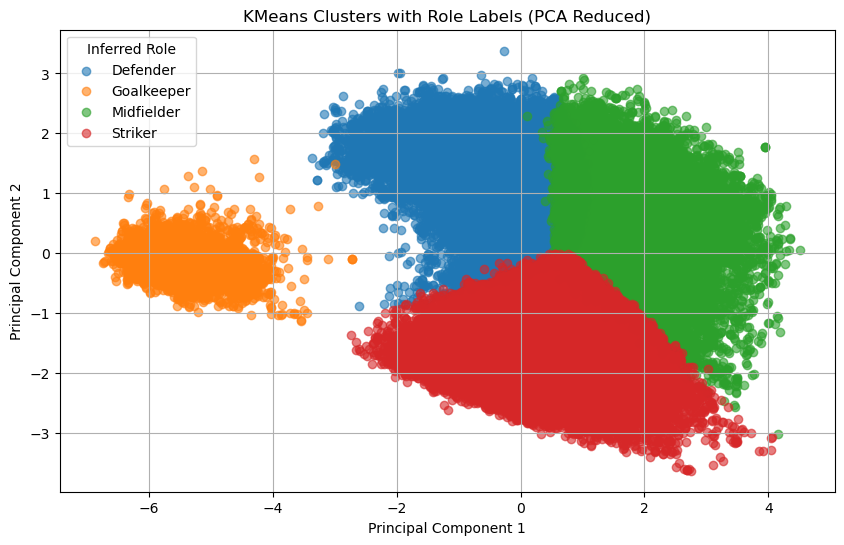

In [59]:
from sklearn.decomposition import PCA

# Step 1: Map cluster number to majority role
cluster_to_role = cluster_data.groupby('Cluster')['Role'].agg(lambda x: x.value_counts().idxmax()).to_dict()

# Step 2: Add new column with descriptive cluster name
cluster_data['Cluster Role'] = cluster_data['Cluster'].map(cluster_to_role)

# Step 3: PCA for visualization
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)
cluster_data['PCA1'] = components[:, 0]
cluster_data['PCA2'] = components[:, 1]

# Step 4: Plot with named clusters
plt.figure(figsize=(10, 6))
for role in sorted(cluster_data['Cluster Role'].unique()):
    subset = cluster_data[cluster_data['Cluster Role'] == role]
    plt.scatter(subset['PCA1'], subset['PCA2'], label=role, alpha=0.6)

plt.title('KMeans Clusters with Role Labels (PCA Reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Inferred Role')
plt.grid(True)
plt.show()


### Observations

The KMeans clustering revealed four distinct player groups that closely aligned with real-world football roles: strikers, midfielders, defenders, and goalkeepers. By using relevant performance attributes such as finishing, ball control, passing, tackling, and reflexes, the model was able to naturally separate players into meaningful clusters. The goalkeepers formed a clearly distinct cluster due to their unique skill set, while midfielders and defenders showed moderate overlap, reflecting the fluid nature of those positions. The PCA visualization supported these distinctions, highlighting the model’s effectiveness in capturing underlying player structure. This demonstrates how unsupervised learning can be a valuable tool in sports analytics for identifying latent roles based on player characteristics.

### Insights
The KMeans clustering distinctly grouped players based on key performance attributes, revealing how specific skills drive role differentiation. Goalkeepers clustered tightly due to their unique dominance in GKReflexes, GKHandling, and GKPositioning, which are near-zero for all other players—this sharp contrast made them easily separable in the feature space. Strikers formed a separate cluster largely because of their high Finishing, BallControl, and Dribbling, attributes essential for offensive pressure and goal-scoring. Midfielders were characterized by more balanced skills across ShortPassing, BallControl, and Dribbling, which allow for fluid playmaking and adaptability on the pitch. Defenders, meanwhile, showed strength in StandingTackle and SlidingTackle, anchoring their role as the last line before the goalkeeper. The clustering algorithm captured these attribute-driven patterns, with midfielders and defenders showing moderate overlap, reflecting real-world tactical flexibility. This clustering suggests that even without position labels, players' roles can be inferred directly from their statistical fingerprints, providing a powerful tool for role classification and player evaluation in football analytics.

## Future Work
- Use clustering or dimensionality reduction to group players by role or playstyle.
- Develop predictive models to estimate future ratings.
- Apply classification to distinguish elite vs non-elite players based on attributes.
